# Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import string
import ast
import json
import difflib
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import resample

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import lightgbm as lgb
from sklearn.naive_bayes import MultinomialNB

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout


# Users Analysis


In [17]:
# Loading Users Data
users = pd.read_csv("users.csv", parse_dates=["createdAt"])
users.head()



/tmp/ipython-input-3546251963.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv("users.csv", parse_dates=["createdAt"])


,user.uid,createdAt,source,isAnonymous,referralsCount,city,language,googleId,appleId,facebookId,referral.medium,referral.source,referral.type,favouriteZones
0,09gqlmpl9bn82gwyct3aetbcdp,2024-03-08,website,False,0.0,Aachen,en,True,NaN,NaN,NaN,NaN,NaN,NaN
1,87aezxkbjcfr1zgs6u3dt1cqvl,2022-11-07,app,False,NaN,Aachen,de,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ez4oclwv92ofoeklnccp4nflgz,2019-03-03,website,False,NaN,Aachen,it,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ud3cuumrysslvy5hzgsq6ygovh,2022-03-16,website,False,NaN,Aachen,en,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,y35dhzdewid6nzq5ctivwcogxd,2022-12-15,website,False,NaN,Aachen,en,True,NaN,NaN,NaN,NaN,NaN,NaN


### data preparation

In [18]:
# Check the data types of each column
users.dtypes

,0
user.uid,object
createdAt,datetime64[ns]
source,object
isAnonymous,object
referralsCount,float64
city,object
language,object
googleId,object
appleId,object
facebookId,object


In [19]:
# Show NaN count and percentage for each column
nan_summary_users = pd.DataFrame({
    "NaN_count": users.isna().sum(),
    "NaN_percent": (users.isna().sum() / len(users)) * 100
})
print(nan_summary_users)




                 NaN_count  NaN_percent
user.uid                 0     0.000000
createdAt            12759     1.751171
source                   0     0.000000
isAnonymous          68826     9.446361
referralsCount      551044    75.630732
city                399206    54.790982
language            235345    32.301077
googleId            574684    78.875319
appleId             716951    98.401450
facebookId          665823    91.384138
referral.medium     706124    96.915446
referral.source     705399    96.815940
referral.type       705481    96.827194
favouriteZones      723967    99.364396


In [20]:
# Remove columns that are almost empty (more than 90% NaN)
threshold = 0.9
cols_to_drop = users.columns[users.isna().mean() > threshold]
users = users.drop(columns=cols_to_drop)

# Handling missing categorical values
categorical_cols = ["language", "city"]
for col in categorical_cols:
    if col in users.columns:
        users[col] = users[col].fillna("unknown")

# Handling Boolean/numeric values
if "isAnonymous" in users.columns:
    users["isAnonymous"] = users["isAnonymous"].fillna(False)

# Date management (delete rows without ‘createdAt’)
if "createdAt" in users.columns:
    users = users.dropna(subset=["createdAt"])

# Consolidation of login providers
provider_cols = ["googleId", "appleId", "facebookId"]

# Create a Boolean series of the same length for each provider
mask_google = users["googleId"].notna() if "googleId" in users.columns else pd.Series([False] * len(users), index=users.index)
mask_apple  = users["appleId"].notna()  if "appleId"  in users.columns else pd.Series([False] * len(users), index=users.index)
mask_fb     = users["facebookId"].notna() if "facebookId" in users.columns else pd.Series([False] * len(users), index=users.index)

users["signup_provider"] = np.select(
    [mask_google, mask_apple, mask_fb],
    ["google", "apple", "facebook"],
    default="unknown"
)

# Delete the original columns if they exist
users = users.drop(columns=[col for col in provider_cols if col in users.columns])


# New summary of NaNs
nan_summary_users = pd.DataFrame({
    "NaN_count": users.isna().sum(),
    "NaN_percent": (users.isna().sum() / len(users)) * 100
})

print(nan_summary_users)


/tmp/ipython-input-4106855436.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  users["isAnonymous"] = users["isAnonymous"].fillna(False)


                 NaN_count  NaN_percent
user.uid                 0     0.000000
createdAt                0     0.000000
source                   0     0.000000
isAnonymous              0     0.000000
referralsCount      540673    75.529973
city                     0     0.000000
language                 0     0.000000
signup_provider          0     0.000000


In [21]:

# Fill NaN values
users["referralsCount"] = users["referralsCount"].fillna(0)

# New summary of NaNs
nan_summary_users = pd.DataFrame({
    "NaN_count": users.isna().sum(),
    "NaN_percent": (users.isna().sum() / len(users)) * 100
})

print(nan_summary_users)

                 NaN_count  NaN_percent
user.uid                 0          0.0
createdAt                0          0.0
source                   0          0.0
isAnonymous              0          0.0
referralsCount           0          0.0
city                     0          0.0
language                 0          0.0
signup_provider          0          0.0


### User growth trend

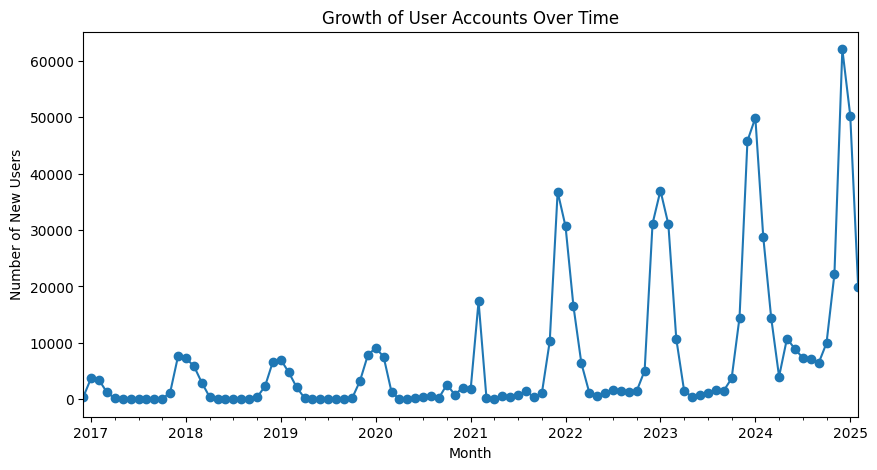

In [22]:
users_per_month = users.groupby(users["createdAt"].dt.to_period("M")).size()
users_per_month.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Growth of User Accounts Over Time")
plt.xlabel("Month")
plt.ylabel("Number of New Users")
plt.show()



### Customer acquisition channels

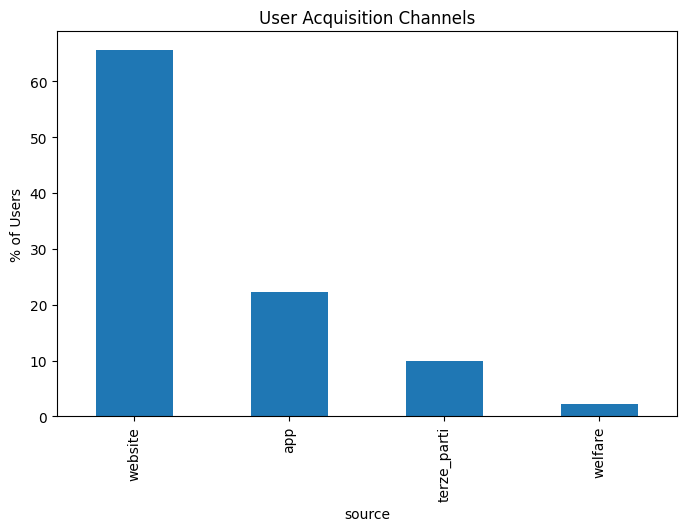

In [23]:
acquisition = users["source"].value_counts(normalize=True) * 100
acquisition.plot(kind="bar", figsize=(8,5))
plt.title("User Acquisition Channels")
plt.ylabel("% of Users")
plt.show()


### Anonymous vs Registered

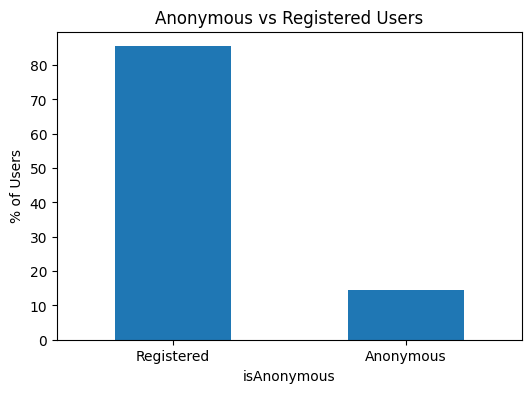

In [24]:
anon_counts = users["isAnonymous"].value_counts(normalize=True) * 100
anon_counts.plot(kind="bar", figsize=(6,4))
plt.title("Anonymous vs Registered Users")
plt.ylabel("% of Users")
plt.xticks([0,1], ["Registered", "Anonymous"], rotation=0)
plt.show()



### Geography and Language

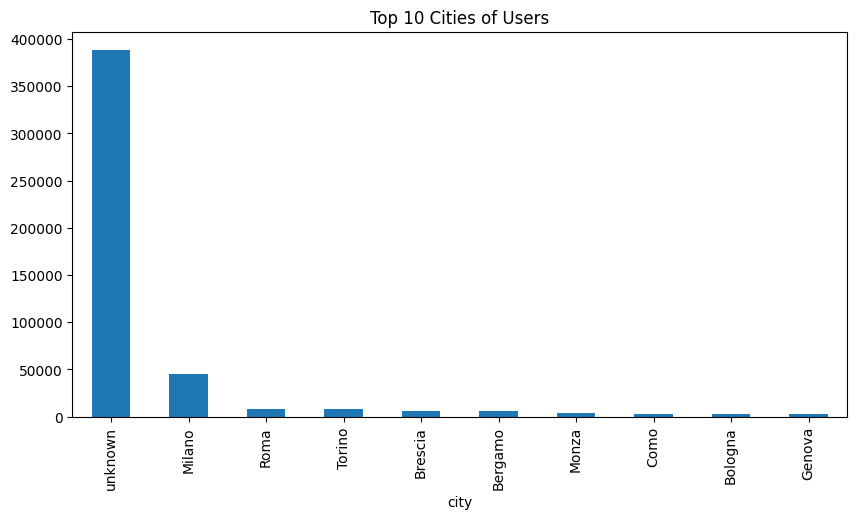

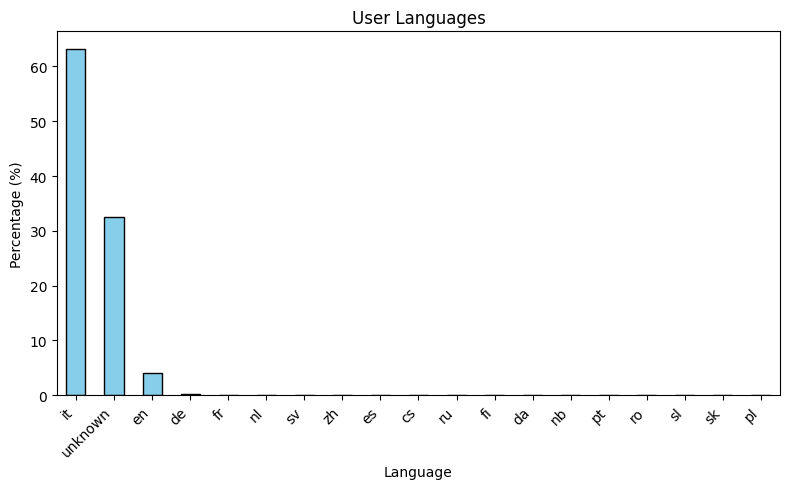

In [25]:
city_counts = users["city"].value_counts().head(10)
city_counts.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Cities of Users")
plt.show()


#Calculate language percentages
language_counts = users["language"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
language_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("User Languages")
plt.ylabel("Percentage (%)")
plt.xlabel("Language")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()




### Registration Modality

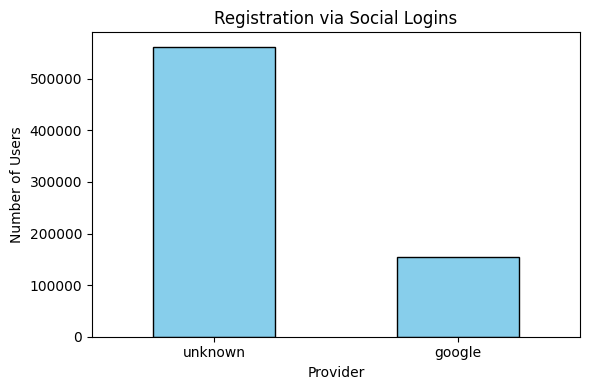

In [26]:
#Count how many users signed up through each provider
provider_counts = users["signup_provider"].value_counts()

#Plot as bar chart
provider_counts.plot(kind="bar", figsize=(6,4), color="skyblue", edgecolor="black")

plt.title("Registration via Social Logins")
plt.ylabel("Number of Users")
plt.xlabel("Provider")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




### KPI

In [27]:
users["createdAt"] = pd.to_datetime(users["createdAt"], errors="coerce")

# KPIs
total_users = users["user.uid"].nunique()
anonymous_rate = (users["isAnonymous"] == True).mean()
referral_rate = (users["referralsCount"] > 0).mean()
avg_referrals = users["referralsCount"].mean()

# Monthly active users (new signups)
monthly_users = users.groupby(users["createdAt"].dt.to_period("M"))["user.uid"].nunique()
latest_month = monthly_users.index.max()
latest_month_users = monthly_users.loc[latest_month]

# Source distribution
source_counts = users["source"].value_counts(normalize=True).round(3) * 100

# Signup provider distribution
provider_counts = users["signup_provider"].value_counts(normalize=True).round(3) * 100

# Top 5 cities
top_cities = users["city"].value_counts().head(5)

# Top 5 languages
top_languages = users["language"].value_counts(normalize=True).head(5).round(3) * 100

# Print Dashboard
print("===== USERS KPI DASHBOARD =====\n")
print(f"Total Users: {total_users:,}")
print(f"Anonymous Users: {anonymous_rate:.2%}")
print(f"Users with ≥1 referral: {referral_rate:.2%}")
print(f"Average referrals per user: {avg_referrals:.2f}")
print(f"New Users in {latest_month}: {latest_month_users}\n")

print("Users by Source (%):")
print(source_counts, "\n")

print("Signup Provider Distribution (%):")
print(provider_counts, "\n")

print("Top 5 Cities by Users:")
print(top_cities, "\n")

print("Top 5 Languages (%):")
print(top_languages)


===== USERS KPI DASHBOARD =====

Total Users: 715,839
Anonymous Users: 14.54%
Users with ≥1 referral: 0.66%
Average referrals per user: 0.01
New Users in 2025-02: 19954

Users by Source (%):
source
website        65.6
app            22.2
terze_parti    10.0
welfare         2.2
Name: proportion, dtype: float64 

Signup Provider Distribution (%):
signup_provider
unknown    78.5
google     21.5
Name: proportion, dtype: float64 

Top 5 Cities by Users:
city
unknown    388427
Milano      45187
Roma         8517
Torino       7557
Brescia      5832
Name: count, dtype: int64 

Top 5 Languages (%):
language
it         63.2
unknown    32.5
en          4.1
de          0.1
fr          0.0
Name: proportion, dtype: float64


# Profiles Analysis

In [28]:
# Loading Data
profiles = pd.read_csv("profiles.csv", parse_dates=["birthday"])
profiles.head()

,user.uid,profile.uid,birthday,sex,city,height,weight,skibootsSize,level,types
0,tvvgjd4sdgfucn33brkigrnjjv,9oqhfw0zsc5prlkwh9gk,2000-05-23,M,Zwolle,180.0,70,43,beginner,"[""insurance"",""rent"",""rent/ski"",""rent/bike"",""le..."
1,iwu2obhsgzamrxcp4wnoxlf5b0,miejgay5t0m7v7gsjffo,1994-08-07,M,Zurigo,185.0,95,NaN,intermediate,"[""insurance"",""rent/bike"",""rent"",""lesson"",""less..."
2,bmgilq4eatrpt2hhwamnbcqnir,vi88jcuymkmxkandvy3l,1992-05-06,F,Z√ºrich,NaN,NaN,NaN,intermediate,"[""insurance"",""rent/bike"",""rent"",""lesson"",""less..."
3,ysbrr5ve9azqvr1jw72expbnxr,p54s6m0hejd4nucibz4e,1998-02-16,F,Zurich,161.0,56,38,beginner,"[""insurance"",""rent"",""rent/ski"",""rent/bike"",""le..."
4,ysbrr5ve9azqvr1jw72expbnxr,zkzpf8fnha6s4kmc2rwn,1994-05-12,M,Zurich,180.0,80,45,beginner,"[""insurance"",""rent"",""rent/ski"",""rent/bike"",""le..."


### data preparation

In [29]:
# Show NaN count and percentage for each column
nan_summary_profiles = pd.DataFrame({
    "NaN_count": profiles.isna().sum(),
    "NaN_percent": (profiles.isna().sum() / len(profiles)) * 100
})
print(nan_summary_profiles)


              NaN_count  NaN_percent
user.uid              0     0.000000
profile.uid           0     0.000000
birthday           5562     5.724696
sex               26889    27.675539
city              84771    87.250664
height            21387    22.012598
weight            21608    22.240063
skibootsSize      21617    22.249326
level             19781    20.359620
types                 0     0.000000


In [30]:
# Check data types of each column in the profiles table
profiles.dtypes

,0
user.uid,object
profile.uid,object
birthday,datetime64[ns]
sex,object
city,object
height,float64
weight,object
skibootsSize,object
level,object
types,object


In [31]:
# Convert numeric columns
for col in ["weight", "skibootsSize"]:
    profiles[col] = pd.to_numeric(profiles[col], errors="coerce")

# Ensuring that the categorical columns are of type string/object.
for col in ["user.uid", "profile.uid", "sex", "city", "level", "types"]:
    profiles[col] = profiles[col].astype(str)

profiles.dtypes

,0
user.uid,object
profile.uid,object
birthday,datetime64[ns]
sex,object
city,object
height,float64
weight,float64
skibootsSize,float64
level,object
types,object


In [32]:
# birthday -> age calculation
profiles["age"] = pd.to_datetime("today").year - pd.to_datetime(profiles["birthday"], errors="coerce").dt.year
profiles["age"] = profiles["age"].fillna("unknown")

# sex, city, level -> categoricals
for col in ["sex", "city", "level"]:
    if col in profiles.columns:
        profiles[col] = profiles[col].fillna("unknown")

# height, weight, skibootsSize -> numerical
for col in ["height", "weight", "skibootsSize"]:
    if col in profiles.columns:
        profiles[col] = profiles[col].fillna(profiles[col].median())

# Show NaN for each column
nan_summary_profiles = pd.DataFrame({
    "NaN_count": profiles.isna().sum(),
    "NaN_percent": (profiles.isna().sum() / len(profiles)) * 100
})
print(nan_summary_profiles)


              NaN_count  NaN_percent
user.uid              0     0.000000
profile.uid           0     0.000000
birthday           5562     5.724696
sex                   0     0.000000
city                  0     0.000000
height                0     0.000000
weight                0     0.000000
skibootsSize          0     0.000000
level                 0     0.000000
types                 0     0.000000
age                   0     0.000000


### Age Distribution

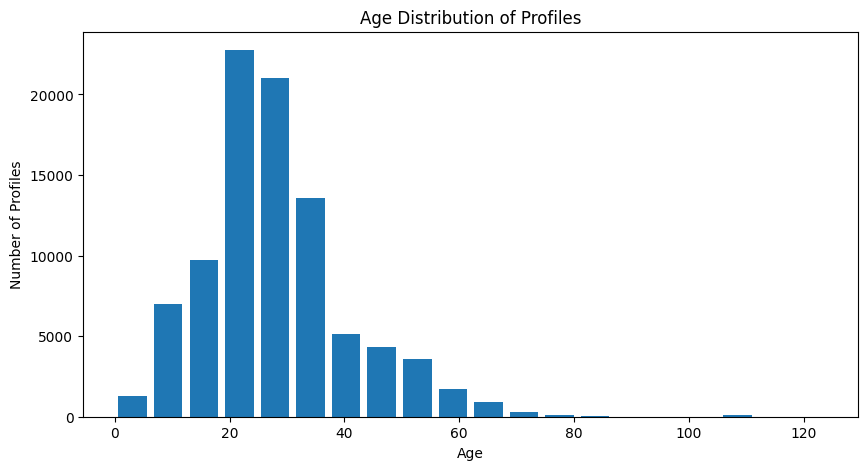

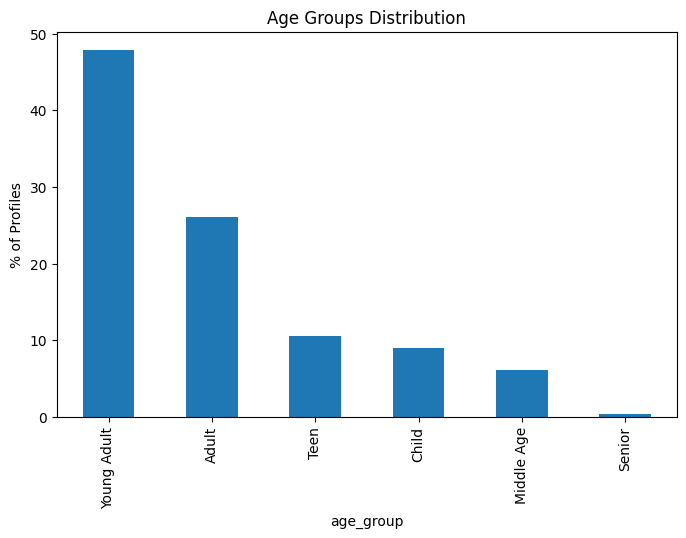

In [33]:
today = pd.to_datetime("today")
profiles["age"] = profiles["birthday"].apply(lambda x: (today - x).days // 365 if pd.notnull(x) else None)

plt.figure(figsize=(10,5))
profiles["age"].dropna().plot(kind="hist", bins=20, rwidth=0.8)
plt.title("Age Distribution of Profiles")
plt.xlabel("Age")
plt.ylabel("Number of Profiles")
plt.show()

# Distribution by age group
bins = [0, 12, 18, 30, 50, 70, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Middle Age", "Senior"]
profiles["age_group"] = pd.cut(profiles["age"], bins=bins, labels=labels)

age_groups = profiles["age_group"].value_counts(normalize=True) * 100
age_groups.plot(kind="bar", figsize=(8,5))
plt.title("Age Groups Distribution")
plt.ylabel("% of Profiles")
plt.show()

### Sex

In [34]:
# Check unique
profiles["sex"].unique()

array(['M', 'F', 'nan', 'Uomo', 'Maschio', '""', 'm', 'maschio'],
      dtype=object)

In [35]:
# Sex Coloumn Cleaning
profiles["sex_clean"] = profiles["sex"].str.strip().str.lower()

mapping_sex = {
    "m": "Male", "maschio": "Male", "uomo": "Male",
    "f": "Female", "femmina": "Female", "donna": "Female",
    "": "Unknown", '""': "Unknown", "nan": "Unknown"
}

profiles["sex_clean"] = profiles["sex_clean"].replace(mapping_sex)
profiles["sex_clean"] = profiles["sex_clean"].str.capitalize()  # "Male", "Female"

print(profiles["sex_clean"].value_counts(dropna=False))

sex_clean
Male       41575
Female     28683
Unknown    26900
Name: count, dtype: int64


In [36]:
# Check unique
profiles["sex_clean"].unique()

array(['Male', 'Female', 'Unknown'], dtype=object)

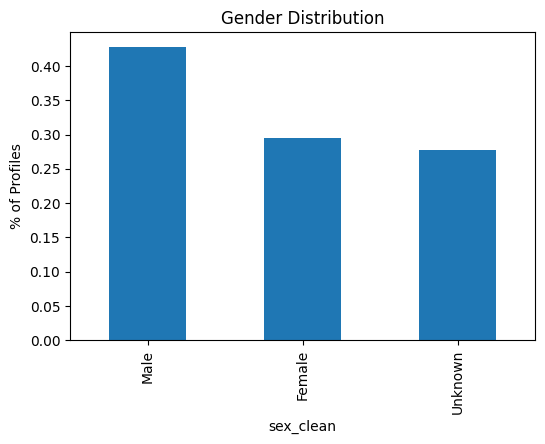

In [37]:
profiles["sex_clean"].value_counts(normalize=True).plot(kind="bar", figsize=(6,4))
plt.title("Gender Distribution")
plt.ylabel("% of Profiles")
plt.show()

### City

In [38]:
# Clean 'city' column
profiles["city_clean"] = profiles["city"].str.strip().str.title()
print(profiles["city_clean"].value_counts().head(10))

city_clean
Nan        84771
Milano      2009
Torino       754
Roma         340
Bergamo      159
Monza        143
Brescia      128
Bologna      126
London       102
Como          91
Name: count, dtype: int64


### height and weight

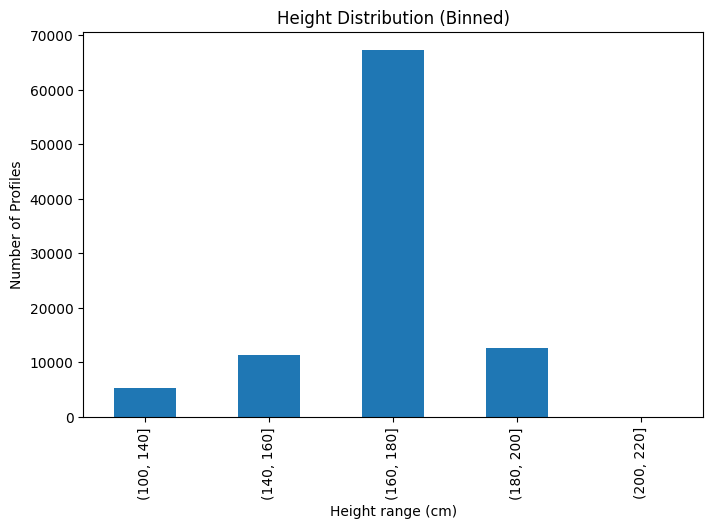

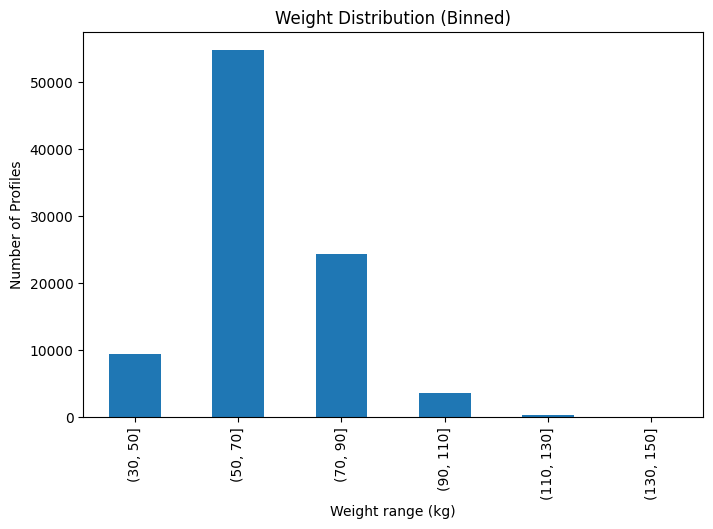

In [39]:

# Outlier filtering
profiles["height_clean"] = profiles["height"].where((profiles["height"] >= 100) & (profiles["height"] <= 220))
profiles["weight_clean"] = profiles["weight"].where((profiles["weight"] >= 30) & (profiles["weight"] <= 150))

# Height with binning
profiles["height_bin"] = pd.cut(profiles["height_clean"], bins=[100,140,160,180,200,220])
profiles["height_bin"].value_counts().sort_index().plot(kind="bar", figsize=(8,5))
plt.title("Height Distribution (Binned)")
plt.xlabel("Height range (cm)")
plt.ylabel("Number of Profiles")
plt.show()

# Weight with binning
profiles["weight_bin"] = pd.cut(profiles["weight_clean"], bins=[30,50,70,90,110,130,150])
profiles["weight_bin"].value_counts().sort_index().plot(kind="bar", figsize=(8,5))
plt.title("Weight Distribution (Binned)")
plt.xlabel("Weight range (kg)")
plt.ylabel("Number of Profiles")
plt.show()


### Ski level

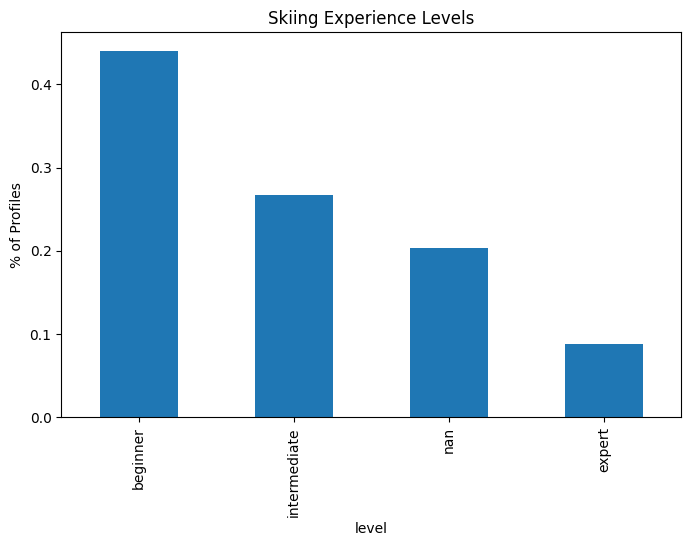

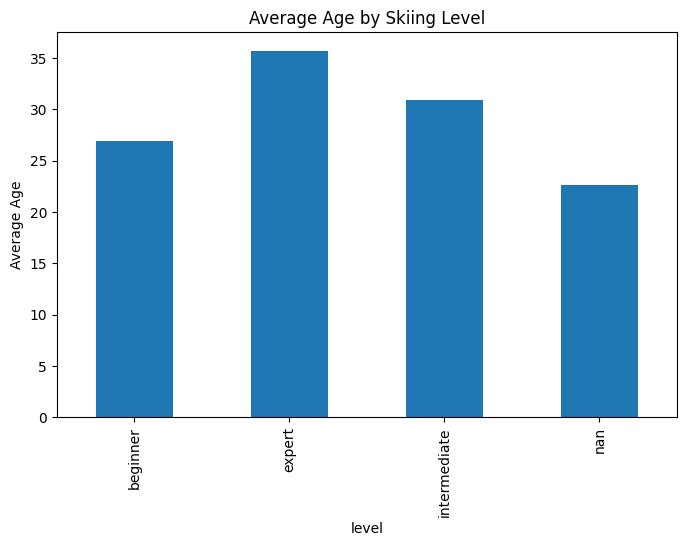

In [40]:
profiles["level"].value_counts(normalize=True).plot(kind="bar", figsize=(8,5))
plt.title("Skiing Experience Levels")
plt.ylabel("% of Profiles")
plt.show()

# Average age by level
avg_age_by_level = profiles.groupby("level")["age"].mean().dropna()
avg_age_by_level.plot(kind="bar", figsize=(8,5))
plt.title("Average Age by Skiing Level")
plt.ylabel("Average Age")
plt.show()

### Types of services



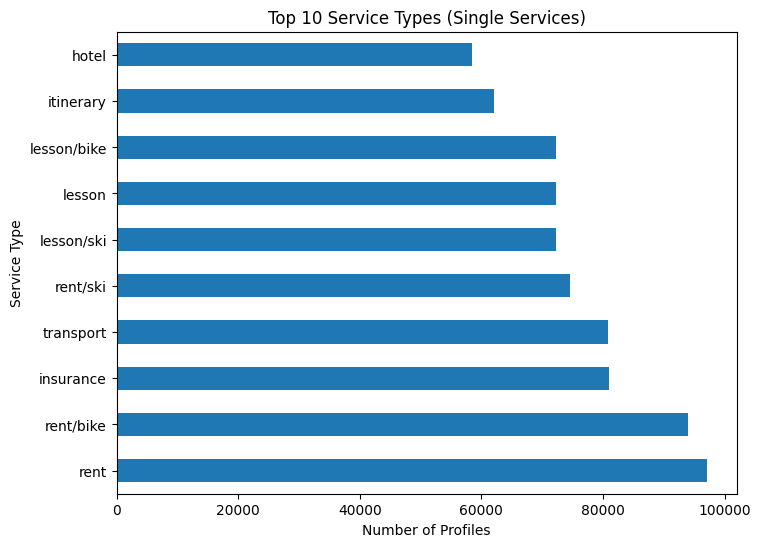

In [41]:
# Convert string to true list
profiles["types_list"] = profiles["types"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Explode lists into single lines
types_exploded = profiles.explode("types_list")

# Count the individual types
service_counts = types_exploded["types_list"].value_counts()

# More readable chart
service_counts.head(10).plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Service Types (Single Services)")
plt.xlabel("Number of Profiles")
plt.ylabel("Service Type")
plt.show()


### KPI

In [42]:
# KPIs
total_profiles = profiles["profile.uid"].nunique()
total_users = profiles["user.uid"].nunique()

# % of users with multiple profiles
profiles_per_user = profiles.groupby("user.uid")["profile.uid"].count()
multi_profile_rate = (profiles_per_user > 1).mean()

# Missing birthdays
missing_birthday_rate = profiles["birthday"].isna().mean()

# Age statistics
avg_age = profiles["age"].mean()
median_age = profiles["age"].median()
youngest = profiles["age"].min()
oldest = profiles["age"].max()

# Sex distribution
sex_counts = profiles["sex"].value_counts(normalize=True).round(3) * 100

# Top 5 cities
top_cities = profiles["city"].value_counts().head(5)

# Height & Weight statistics
avg_height = profiles["height"].mean()
avg_weight = profiles["weight"].mean()

# Ski boots size stats
avg_boots = profiles["skibootsSize"].mean()

# Ski level distribution
level_counts = profiles["level"].value_counts(normalize=True).round(3) * 100

# Types distribution
types_counts = profiles["types"].value_counts(normalize=True).round(3) * 100

# Print Dashboard
print("===== PROFILES KPI DASHBOARD =====\n")
print(f"Total Profiles: {total_profiles:,}")
print(f"Total Users with Profiles: {total_users:,}")
print(f"Users with >1 profile: {multi_profile_rate:.2%}\n")

print(f"Missing Birthdays: {missing_birthday_rate:.2%}")
print(f"Average Age: {avg_age:.1f}")
print(f"Median Age: {median_age:.1f}")
print(f"Youngest User: {youngest}")
print(f"Oldest User: {oldest}\n")

print("Sex Distribution (%):")
print(sex_counts, "\n")

print("Top 5 Cities by Profiles:")
print(top_cities, "\n")

print(f"Average Height: {avg_height:.1f} cm")
print(f"Average Weight: {avg_weight:.1f} kg")
print(f"Average Ski Boots Size: {avg_boots:.1f}\n")

print("Ski Level Distribution (%):")
print(level_counts, "\n")

print("Preferred Ski Types Distribution (%):")
print(types_counts)


===== PROFILES KPI DASHBOARD =====

Total Profiles: 97,158
Total Users with Profiles: 64,238
Users with >1 profile: 31.85%

Missing Birthdays: 5.72%
Average Age: 27.8
Median Age: 26.0
Youngest User: 0.0
Oldest User: 124.0

Sex Distribution (%):
sex
M          42.8
F          29.5
nan        27.7
""          0.0
Maschio     0.0
Uomo        0.0
m           0.0
maschio     0.0
Name: proportion, dtype: float64 

Top 5 Cities by Profiles:
city
nan       84771
Milano     1654
Torino      588
Roma        276
milano      190
Name: count, dtype: int64 

Average Height: 174.0 cm
Average Weight: 65.6 kg
Average Ski Boots Size: 41.0

Ski Level Distribution (%):
level
beginner        44.1
intermediate    26.8
nan             20.4
expert           8.8
Name: proportion, dtype: float64 

Preferred Ski Types Distribution (%):
types
["insurance","rent","rent/ski","rent/bike","lesson","lesson/ski","lesson/bike","hotel","travel","transport"]                                                               18

# Cards


In [43]:
# Loading Data
cards = pd.read_csv("cards.csv")
cards.head()

/tmp/ipython-input-4193863932.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cards = pd.read_csv("cards.csv")


,card.uid,assignedAt,birthday,status,user.uid
0,00000001,2025-02-01,2018-07-02,pending,6m8fx3mvanac7bcltkx79lbxjs
1,00000011,2023-03-13,1985-02-21,pending,ogv7xt7089clwmbgmtam35zvjq
2,00000022,2022-01-14,1985-09-28,pending,naxfhkqjhcqrx3nv6ge9kxenth
3,00000033,NaN,NaN,not-assigned,NaN
4,00000044,2018-01-03,NaN,valid,70uymyvsxtusxwrrgva0bfen8q


### data preparation

In [44]:
# Check data types of each column in the cards table
cards.dtypes

,0
card.uid,object
assignedAt,object
birthday,object
status,object
user.uid,object


In [45]:
# Convert specified columns to datetime format
for col in ["assignedAt", "birthday"]:
    cards[col] = pd.to_datetime(cards[col], errors="coerce")
cards.dtypes

,0
card.uid,object
assignedAt,datetime64[ns]
birthday,datetime64[ns]
status,object
user.uid,object


In [46]:
# Show NaN count and percentage for each column
nan_summary_cards = pd.DataFrame({
    "NaN_count": cards.isna().sum(),
    "NaN_percent": (cards.isna().sum() / len(cards)) * 100
})
print(nan_summary_cards)

            NaN_count  NaN_percent
card.uid            0     0.000000
assignedAt     477688    59.278489
birthday       499797    62.022096
status              0     0.000000
user.uid       475388    58.993072


In [47]:
# Calculate age by subtracting the birth year from the current year
cards["age"] = pd.to_datetime("today").year - pd.to_datetime(cards["birthday"], errors="coerce").dt.year

# Replace missing ages with the string "unknown"
cards["age"] = cards["age"].fillna("unknown")

# Drop rows where 'birthday' is NaN
cards = cards.dropna(subset=["birthday"])

# Remove rows where 'user.uid' is missing (NaN)
cards = cards.dropna(subset=["user.uid"])

# Create a DataFrame summarizing the count and percentage of NaN values for each column
nan_summary_cards = pd.DataFrame({
    "NaN_count": cards.isna().sum(),
    "NaN_percent": (cards.isna().sum() / len(cards)) * 100
})

print(nan_summary_cards)


            NaN_count  NaN_percent
card.uid            0     0.000000
assignedAt       2695     0.881157
birthday            0     0.000000
status              0     0.000000
user.uid            0     0.000000
age                 0     0.000000


In [48]:
# Remove rows where 'assignedAt' is missing (NaN)
cards = cards.dropna(subset=["assignedAt"])

# Create a DataFrame summarizing the count and percentage of NaN values for each column
nan_summary_cards = pd.DataFrame({
    "NaN_count": cards.isna().sum(),
    "NaN_percent": (cards.isna().sum() / len(cards)) * 100
})

print(nan_summary_cards)


            NaN_count  NaN_percent
card.uid            0          0.0
assignedAt          0          0.0
birthday            0          0.0
status              0          0.0
user.uid            0          0.0
age                 0          0.0


### Card Status


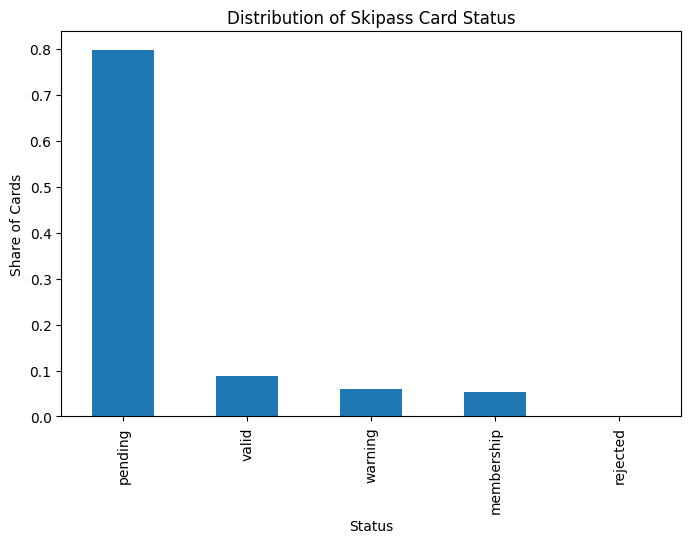

In [49]:
cards["status"].value_counts(normalize=True).plot(kind="bar", figsize=(8,5))
plt.title("Distribution of Skipass Card Status")
plt.ylabel("Share of Cards")
plt.xlabel("Status")
plt.show()


### Demographic Analysis

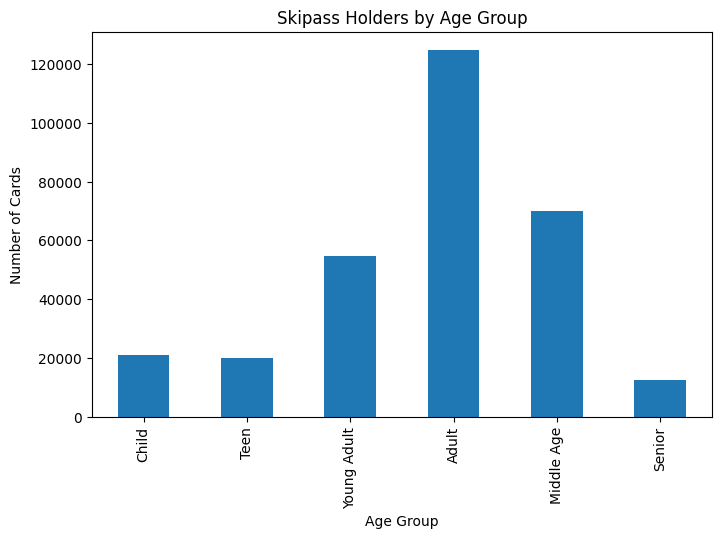

In [50]:
# Create age groups
bins = [0,12,17,25,40,60,100]
labels = ["Child","Teen","Young Adult","Adult","Middle Age","Senior"]
cards["age_group"] = pd.cut(cards["age"], bins=bins, labels=labels, right=True)

# Distribution by age group
cards["age_group"].value_counts().sort_index().plot(kind="bar", figsize=(8,5))
plt.title("Skipass Holders by Age Group")
plt.ylabel("Number of Cards")
plt.xlabel("Age Group")
plt.show()


### Those who buy for themselves vs. those who buy for others

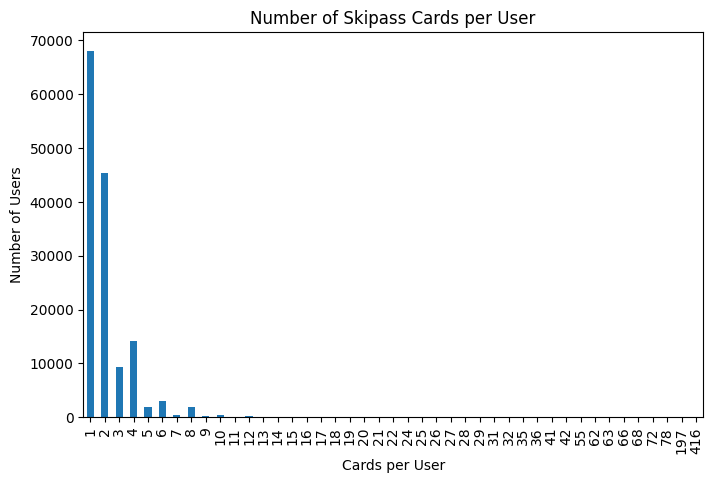

Users with unusually many cards:
user.uid
ip38b9g4qkrwukjiworctfhcjb    416
if0ncowykvpicvegdddek2whnu    197
u3np5ayx76d5ic6c4odjrlndct     78
2yodbdlwkgct5yno74ukkvtgkf     72
k7y7c6asavg7q7jv9ifyzgkwtu     68
                             ... 
amwklptgqdvj89qewoslcnnhl4      4
amwi9czpamesh8obi8uxtb9kyt      4
amvn8whvftssq5j7akrrkrzh3h      4
amuvvwpzaxtrmissxgvnidroho      4
flqe89vf5igja1riu2wesx3tfi      4
Name: card.uid, Length: 22468, dtype: int64


In [51]:
# Count number of cards per user
cards_per_user = cards.groupby("user.uid")["card.uid"].count()

# Distribution of the number of cards per user
cards_per_user.value_counts().sort_index().plot(kind="bar", figsize=(8,5))
plt.title("Number of Skipass Cards per User")
plt.xlabel("Cards per User")
plt.ylabel("Number of Users")
plt.show()

# Identify outlier users
Q1 = cards_per_user.quantile(0.25)
Q3 = cards_per_user.quantile(0.75)
IQR = Q3 - Q1
outliers = cards_per_user[cards_per_user > Q3 + 1.5 * IQR]
print("Users with unusually many cards:")
print(outliers.sort_values(ascending=False))

### Combined analysis: age × status

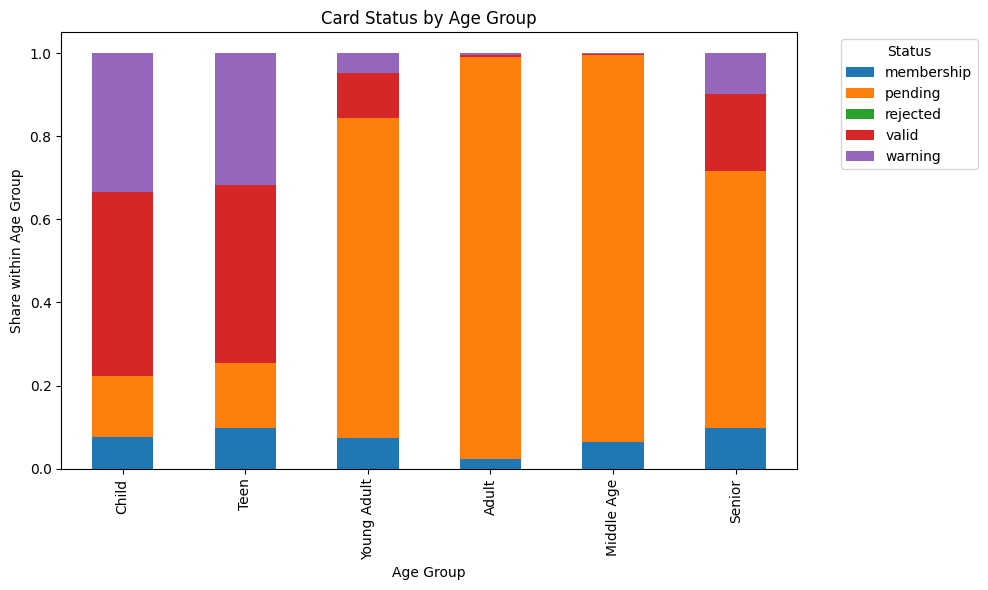

In [52]:
# Create a cross-tabulation of 'age_group' vs 'status'
age_status = pd.crosstab(cards["age_group"], cards["status"], normalize="index")

ax = age_status.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Card Status by Age Group")

plt.ylabel("Share within Age Group")

plt.xlabel("Age Group")

plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()



### KPI

In [53]:
# KPIs
total_cards = cards["card.uid"].nunique()
total_users = cards["user.uid"].nunique()

# Cards per user
cards_per_user = cards.groupby("user.uid")["card.uid"].count()
avg_cards_per_user = cards_per_user.mean()
multi_card_rate = (cards_per_user > 1).mean()

# Status distribution
status_counts = cards["status"].value_counts(normalize=True).round(3) * 100

# AssignedAt
cards["assignedAt"] = pd.to_datetime(cards["assignedAt"], errors="coerce")
cards_per_year = cards["assignedAt"].dt.year.value_counts().sort_index()

# Age stats
avg_age = cards["age"].mean()
median_age = cards["age"].median()
youngest = cards["age"].min()
oldest = cards["age"].max()

# Print Dashboard
print("===== CARDS KPI DASHBOARD =====\n")
print(f"Total Cards: {total_cards:,}")
print(f"Total Users with Cards: {total_users:,}")
print(f"Average Cards per User: {avg_cards_per_user:.2f}")
print(f"Users with >1 Card: {multi_card_rate:.2%}\n")

print("Card Status Distribution (%):")
print(status_counts, "\n")

print("Cards Assigned per Year:")
print(cards_per_year, "\n")

print(f"Average Age: {avg_age:.1f}")
print(f"Median Age: {median_age:.1f}")
print(f"Youngest Cardholder: {youngest}")
print(f"Oldest Cardholder: {oldest}")


===== CARDS KPI DASHBOARD =====

Total Cards: 250,869
Total Users with Cards: 145,227
Average Cards per User: 2.09
Users with >1 Card: 53.09%

Card Status Distribution (%):
status
pending       79.8
valid          8.9
warning        5.9
membership     5.4
rejected       0.0
Name: proportion, dtype: float64 

Cards Assigned per Year:
assignedAt
2017       41
2018      361
2019      848
2020     1526
2021    20462
2022    47203
2023    93028
2024    91265
2025    48419
Name: count, dtype: int64 

Average Age: 32.8
Median Age: 30.0
Youngest Cardholder: -74.0
Oldest Cardholder: 125.0


# Orders

In [54]:
# Loading Data
orders = pd.read_csv("orders.csv", parse_dates=["createdAt"])
orders.head()



/tmp/ipython-input-4166030632.py:2: DtypeWarning: Columns (5,11) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv("orders.csv", parse_dates=["createdAt"])


,order.uid,user.uid,createdAt,createdAtTime,paymentGateway,paymentBrand,pickup,pickupComplete,source,tenant,paymentAttempts,timeZone,clientInfo
0,4y9zqqvldfqr9n2xnu,nu7fhz41rzwbkabapcufr6g18r,2024-07-01,2024-07-01 19:41:44,stripe,visa,False,False,website,snowit_esterno,2,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."
1,termljwsr2gecnzwks,ghol7lwjlhewwvasejlxa9fv00,2024-07-01,2024-07-01 18:34:12,discount,NaN,False,False,website,snowit_esterno,1,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."
2,ko8axscf5grobnz9in,nhuh3scqoktj6n5mnqkvgyh43h,2024-07-01,2024-07-01 16:08:26,discount,NaN,False,False,website,snowit_esterno,1,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."
3,tu8b9haokkimu72aza,oyekz0wyxcplvrpencpuue6sdt,2024-07-01,2024-07-01 16:02:11,stripe,mastercard,False,False,website,snowit_esterno,2,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."
4,a8mvwuv6ileh9aqblu,1p0ocryxz4ts2wtsi1bawtjndt,2024-07-01,2024-07-01 15:46:12,stripe,NaN,False,False,website,tribala,2,NaN,"{""browser"":{""major"":""125"",""name"":""Chrome"",""ver..."


### data preparation

In [55]:
# Check data types of each column in the order table
orders.dtypes

,0
order.uid,object
user.uid,object
createdAt,datetime64[ns]
createdAtTime,object
paymentGateway,object
paymentBrand,object
pickup,bool
pickupComplete,bool
source,object
tenant,object


In [56]:
#Convert 'createdAtTime' to datetime format
orders["createdAtTime"] = pd.to_datetime(orders["createdAtTime"], errors="coerce")

In [57]:
orders.dtypes

,0
order.uid,object
user.uid,object
createdAt,datetime64[ns]
createdAtTime,datetime64[ns]
paymentGateway,object
paymentBrand,object
pickup,bool
pickupComplete,bool
source,object
tenant,object


In [58]:
# Show NaN count and percentage for each column
nan_summary_orders = pd.DataFrame({
    "NaN_count": orders.isna().sum(),
    "NaN_percent": (orders.isna().sum() / len(orders)) * 100
})
print(nan_summary_orders)

                 NaN_count  NaN_percent
order.uid                0     0.000000
user.uid                 0     0.000000
createdAt                0     0.000000
createdAtTime            0     0.000000
paymentGateway           0     0.000000
paymentBrand        185567    33.745590
pickup                   0     0.000000
pickupComplete           0     0.000000
source                 227     0.041280
tenant                 575     0.104564
paymentAttempts          0     0.000000
timeZone            383277    69.699400
clientInfo               0     0.000000


In [59]:
# Remove rows where either 'source' or 'tenant' is missing
orders = orders.dropna(subset=["source", "tenant"])

# Fill missing values in 'paymentBrand' and 'timeZone' columns with the string "unknown"
for col in ["paymentBrand", "timeZone"]:
    orders[col] = orders[col].fillna("unknown")

# Create a DataFrame summarizing the count and percentage of NaN values for each column
nan_summary_orders = pd.DataFrame({
    "NaN_count": orders.isna().sum(),
    "NaN_percent": (orders.isna().sum() / len(orders)) * 100
})

print(nan_summary_orders)

                 NaN_count  NaN_percent
order.uid                0          0.0
user.uid                 0          0.0
createdAt                0          0.0
createdAtTime            0          0.0
paymentGateway           0          0.0
paymentBrand             0          0.0
pickup                   0          0.0
pickupComplete           0          0.0
source                   0          0.0
tenant                   0          0.0
paymentAttempts          0          0.0
timeZone                 0          0.0
clientInfo               0          0.0


### Order trends over time

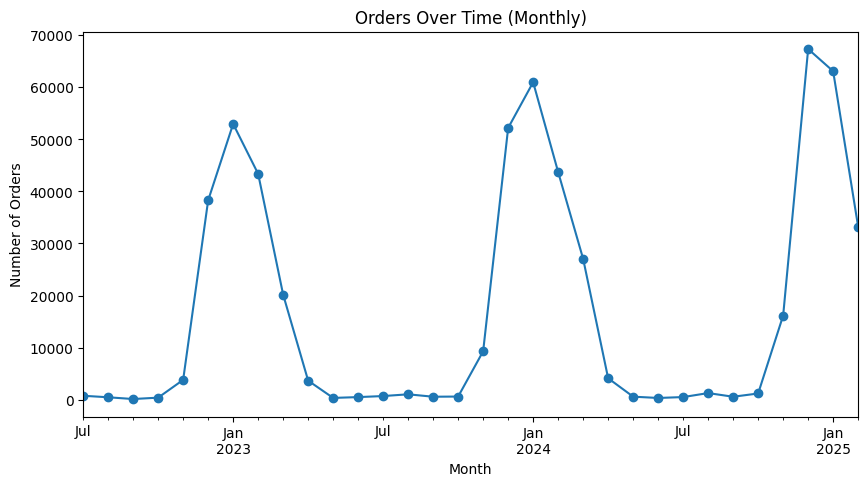

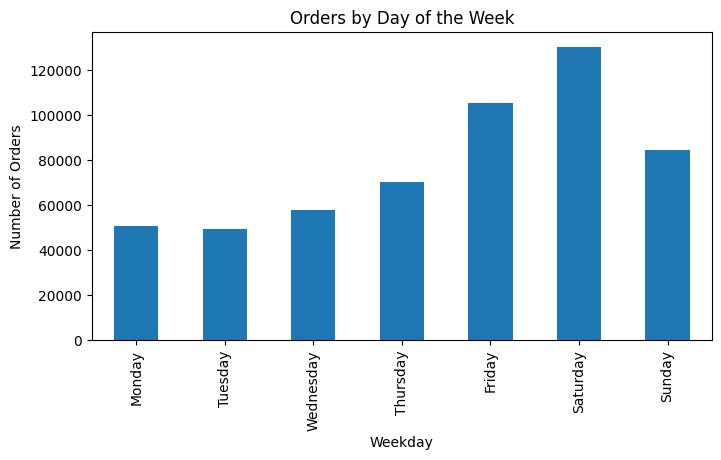

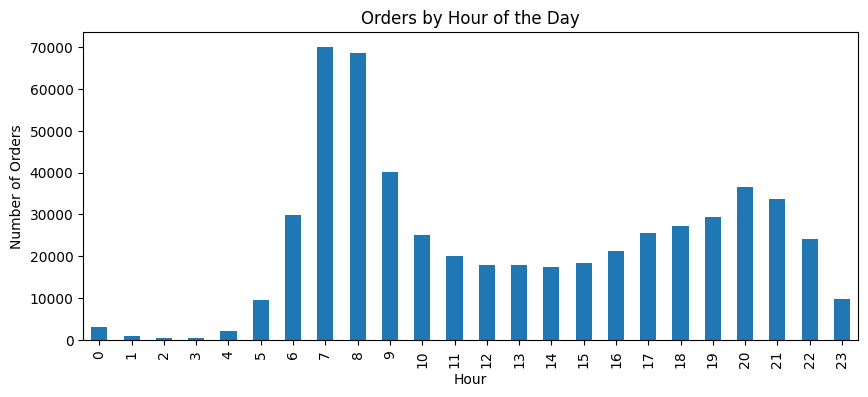

In [60]:
# Convert 'createdAt' column to datetime
orders["createdAt"] = pd.to_datetime(orders["createdAt"], errors="coerce")

# Convert 'createdAtTime' column to datetime
orders["createdAtTime"] = pd.to_datetime(orders["createdAtTime"], errors="coerce")

# Group orders by month and count the number of orders per month
orders_per_month = orders.groupby(orders["createdAt"].dt.to_period("M")).size()

# Plot monthly orders as a line chart with markers
orders_per_month.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Orders Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

# Extract the weekday name from 'createdAtTime'
orders["weekday"] = orders["createdAtTime"].dt.day_name()

# Count orders per weekday
orders["weekday"].value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind="bar", figsize=(8,4))
plt.title("Orders by Day of the Week")
plt.ylabel("Number of Orders")
plt.xlabel("Weekday")
plt.show()

# Extract the hour from 'createdAtTime'
orders["hour"] = orders["createdAtTime"].dt.hour

# Count orders per hour
orders["hour"].value_counts().sort_index().plot(kind="bar", figsize=(10,4))
plt.title("Orders by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.show()

### Purchase channels (App vs Web)

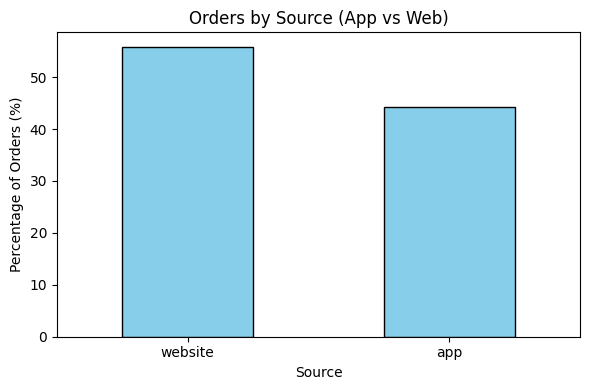

In [61]:
# Compute counts and percentages
source_counts = orders["source"].value_counts()
source_percent = 100 * source_counts / source_counts.sum()

source_percent.plot(kind="bar", figsize=(6,4), color="skyblue", edgecolor="black")
plt.title("Orders by Source (App vs Web)")
plt.ylabel("Percentage of Orders (%)")
plt.xlabel("Source")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Payment methods



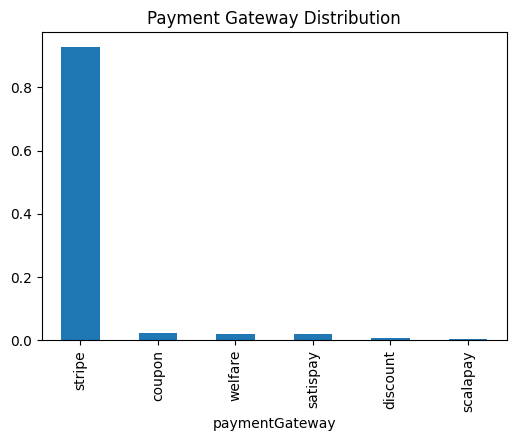

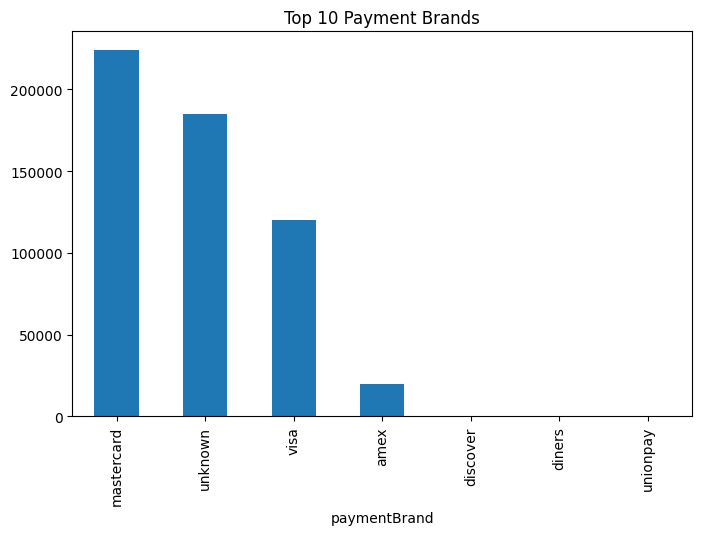

In [62]:
orders["paymentGateway"].value_counts(normalize=True).plot(kind="bar", figsize=(6,4))
plt.title("Payment Gateway Distribution")
plt.show()

orders["paymentBrand"].value_counts().head(10).plot(kind="bar", figsize=(8,5))
plt.title("Top 10 Payment Brands")
plt.show()


### Pickup and logistic

In [63]:
pickup_rate = orders["pickup"].mean()
pickup_complete_rate = orders["pickupComplete"].mean()
print(f"Orders with physical pickup: {pickup_rate:.2%}")
print(f"Pickups successfully completed: {pickup_complete_rate:.2%}")

Orders with physical pickup: 18.19%
Pickups successfully completed: 18.89%


### Delay in payment

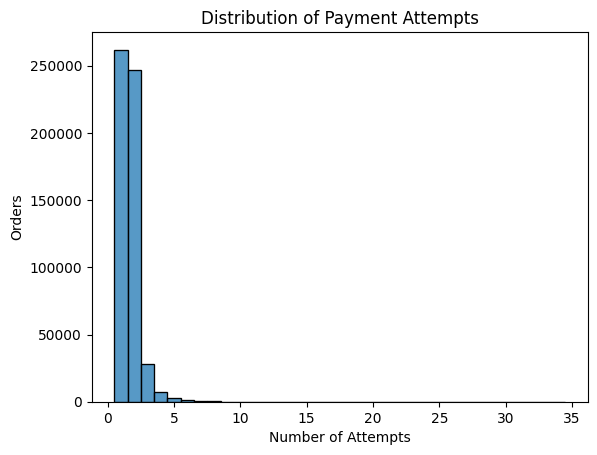

Orders with more than one payment attempt: 52.30%

Friction by Source:
 source
app        0.558825
website    0.494686
Name: paymentAttempts, dtype: float64


In [64]:
sns.histplot(orders["paymentAttempts"], bins=range(1,7), discrete=True)
plt.title("Distribution of Payment Attempts")
plt.xlabel("Number of Attempts")
plt.ylabel("Orders")
plt.show()

friction_rate = (orders["paymentAttempts"] > 1).mean()
print(f"Orders with more than one payment attempt: {friction_rate:.2%}")

friction_by_source = orders.groupby("source")["paymentAttempts"].apply(lambda x: (x>1).mean())
print("\nFriction by Source:\n", friction_by_source)

### User segmentation

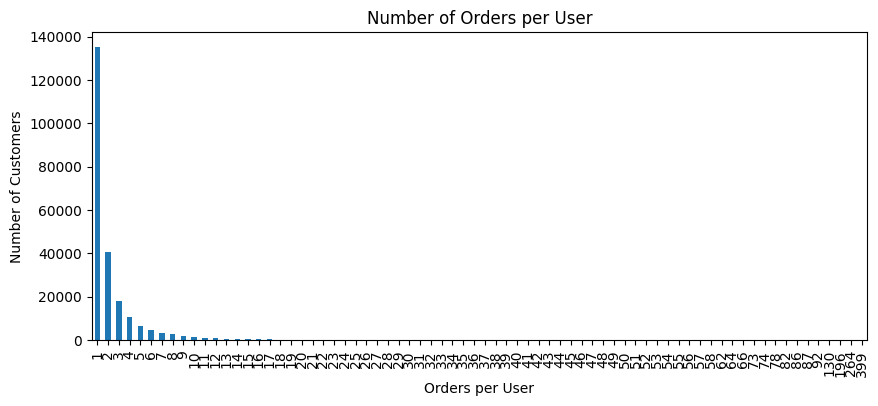

Percentage of customers with more than one order: 41.56%


In [65]:
orders_per_user = orders.groupby("user.uid")["order.uid"].count()

# Distribution of the number of orders per customer
orders_per_user.value_counts().sort_index().plot(kind="bar", figsize=(10,4))
plt.title("Number of Orders per User")
plt.xlabel("Orders per User")
plt.ylabel("Number of Customers")
plt.show()

# Regular vs. occasional customers
repeat_rate = (orders_per_user > 1).mean()
print(f"Percentage of customers with more than one order: {repeat_rate:.2%}")

### KPI

In [66]:
orders["createdAt"] = pd.to_datetime(orders["createdAt"], errors="coerce")
orders["createdAtTime"] = pd.to_datetime(orders["createdAtTime"], errors="coerce")

# KPIs
total_orders = orders["order.uid"].nunique()
total_users = orders["user.uid"].nunique()
orders_per_user = orders.groupby("user.uid")["order.uid"].count()

avg_orders_per_user = orders_per_user.mean()
repeat_rate = (orders_per_user > 1).mean()

# Time distribution
orders_per_month = orders["createdAt"].dt.to_period("M").value_counts().sort_index()
first_order = orders["createdAt"].min()
last_order = orders["createdAt"].max()

# Payment info
payment_gateway_dist = orders["paymentGateway"].value_counts(normalize=True).round(3) * 100
top_payment_brands = orders["paymentBrand"].value_counts().head(5)

# Pickup
pickup_rate = orders["pickup"].mean()
pickup_complete_rate = orders["pickupComplete"].mean()

# Source
source_dist = orders["source"].value_counts(normalize=True).round(3) * 100

# Tenant distribution
tenant_top = orders["tenant"].value_counts(normalize=True).head(5).round(3) * 100

# Payment attempts
avg_payment_attempts = orders["paymentAttempts"].mean()
friction_rate = (orders["paymentAttempts"] > 1).mean()

# Print Dashboard
print("===== ORDERS KPI DASHBOARD =====\n")
print(f"Total Orders: {total_orders:,}")
print(f"Total Users with Orders: {total_users:,}")
print(f"Average Orders per User: {avg_orders_per_user:.2f}")
print(f"Repeat Customer Rate: {repeat_rate:.2%}\n")

print(f"Period Covered: {first_order.date()} → {last_order.date()}")
print("Orders per Month:")
print(orders_per_month, "\n")

print("Payment Gateway Distribution (%):")
print(payment_gateway_dist, "\n")

print("Top Payment Brands:")
print(top_payment_brands, "\n")

print(f"Orders with Pickup: {pickup_rate:.2%}")
print(f"Pickups Successfully Completed: {pickup_complete_rate:.2%}\n")

print("Orders by Source (%):")
print(source_dist, "\n")

print("Top 5 Tenants by Orders (%):")
print(tenant_top, "\n")

print(f"Average Payment Attempts: {avg_payment_attempts:.2f}")
print(f"Orders with >1 Payment Attempt (Friction Rate): {friction_rate:.2%}")


===== ORDERS KPI DASHBOARD =====

Total Orders: 549,105
Total Users with Orders: 231,564
Average Orders per User: 2.37
Repeat Customer Rate: 41.56%

Period Covered: 2022-07-01 → 2025-02-15
Orders per Month:
createdAt
2022-07      754
2022-08      463
2022-09      127
2022-10      391
2022-11     3801
2022-12    38272
2023-01    52947
2023-02    43358
2023-03    20162
2023-04     3653
2023-05      340
2023-06      495
2023-07      698
2023-08     1031
2023-09      568
2023-10      601
2023-11     9295
2023-12    52176
2024-01    60954
2024-02    43703
2024-03    27031
2024-04     4109
2024-05      580
2024-06      329
2024-07      502
2024-08     1268
2024-09      565
2024-10     1190
2024-11    16150
2024-12    67326
2025-01    63066
2025-02    33200
Freq: M, Name: count, dtype: int64 

Payment Gateway Distribution (%):
paymentGateway
stripe      92.9
coupon       2.3
welfare      1.9
satispay     1.8
discount     0.8
scalapay     0.2
Name: proportion, dtype: float64 

Top Payment Bran

# Order Details

In [67]:
# Loading Data
od = pd.read_csv("order_details.csv", parse_dates=False)
od.head()

/tmp/ipython-input-2931308987.py:2: DtypeWarning: Columns (10,13) have mixed types. Specify dtype option on import or set low_memory=False.
  od = pd.read_csv("order_details.csv", parse_dates=False)


,item.uid,order.uid,item.date,product.uid,product.dynamicPricing,item.amount,item.discount,product.type,item.zoneName,product.durationHours,item.profiles,item.variantName,item.slotName,item.snowitcardNumber,item.status
0,rWzvRD0hXOShtjTzx5Ca,4y9zqqvldfqr9n2xnu,2024-07-05,OwhliJmMeSCILiMFiKTp,False,59.5,True,rental~bike,Bormio,12.0,uhozpzih6zz0gb8vsnrl,Rossignol Mandate Shift,L,NaN,fulfilled
1,mmWAugpNnPVHRcePWiiH,termljwsr2gecnzwks,2024-12-27,form:PO9LFLX23J2024,False,0.0,False,hotel~coupon,Pontedilegno-Tonale,NaN,NaN,NaN,NaN,NaN,fulfilled
2,bShIBhXedPkDTmZpmczI,ko8axscf5grobnz9in,2024-07-02,9oNSf7M6J7BNWakW2otU,False,26.0,False,food,Bardonecchia,4.0,NaN,NaN,NaN,NaN,canceled
3,axrCVxzH7eVW2EbaKHho,ko8axscf5grobnz9in,2024-07-02,9oNSf7M6J7BNWakW2otU,False,26.0,False,food,Bardonecchia,4.0,NaN,NaN,NaN,NaN,canceled
4,axrCVxzH7eVW2EbaKHho,ko8axscf5grobnz9in,2024-07-02,9oNSf7M6J7BNWakW2otU,False,-26.0,False,food,Bardonecchia,4.0,NaN,NaN,NaN,NaN,transfer


### data preparation

In [68]:
# Check data types of each column in the order_details table
od.dtypes

,0
item.uid,object
order.uid,object
item.date,object
product.uid,object
product.dynamicPricing,bool
item.amount,float64
item.discount,bool
product.type,object
item.zoneName,object
product.durationHours,float64


In [69]:
# Convert specified columns to datetime format
od["item.date"] = pd.to_datetime(od["item.date"], errors="coerce")
od.dtypes

,0
item.uid,object
order.uid,object
item.date,datetime64[ns]
product.uid,object
product.dynamicPricing,bool
item.amount,float64
item.discount,bool
product.type,object
item.zoneName,object
product.durationHours,float64


In [70]:
# Show updated NaN count and percentage for each column
nan_summary_od = pd.DataFrame({
    "NaN_count": od.isna().sum(),
    "NaN_percent": (od.isna().sum() / len(od)) * 100
})
print(nan_summary_od)

                        NaN_count  NaN_percent
item.uid                        0     0.000000
order.uid                       0     0.000000
item.date                   49060     3.453463
product.uid                     0     0.000000
product.dynamicPricing          0     0.000000
item.amount                     0     0.000000
item.discount                   0     0.000000
product.type                    0     0.000000
item.zoneName              510643    35.945510
product.durationHours      215911    15.198546
item.profiles             1370929    96.503316
item.variantName          1393685    98.105171
item.slotName             1413459    99.497115
item.snowitcardNumber     1010873    71.158022
item.status                     0     0.000000


In [71]:
# Remove rows where 'item.date' is missing
od = od.dropna(subset=["item.date"])

# Fill missing values in 'item.zoneName' and 'item.snowitcardNumber' with 'unknown'
for col in ["item.zoneName", "item.snowitcardNumber"]:
    od[col] = od[col].fillna("unknown")

# Fill missing values in 'product.durationHours' with the median of the column
od["product.durationHours"] = od["product.durationHours"].fillna(od["product.durationHours"].median())

# Drop columns that are almost empty
cols_to_drop = ["item.profiles", "item.variantName", "item.slotName"]
od = od.drop(columns=cols_to_drop)

# Create a DataFrame summarizing the count and percentage of NaN values for each column
nan_summary_od = pd.DataFrame({
    "NaN_count": od.isna().sum(),
    "NaN_percent": (od.isna().sum() / len(od)) * 100
})

# Print the summary of missing values
print(nan_summary_od)



                        NaN_count  NaN_percent
item.uid                        0          0.0
order.uid                       0          0.0
item.date                       0          0.0
product.uid                     0          0.0
product.dynamicPricing          0          0.0
item.amount                     0          0.0
item.discount                   0          0.0
product.type                    0          0.0
item.zoneName                   0          0.0
product.durationHours           0          0.0
item.snowitcardNumber           0          0.0
item.status                     0          0.0


In [72]:
# item.amount -> numeric
def clean_amount(x):
    if pd.isna(x):
        return np.nan
    # If already numeric, just convert to float
    if isinstance(x, (int, float, np.number)):
        return float(x)

    s = str(x).strip()
    # Remove spaces and currency symbols
    s = s.replace(" ", "").replace("€", "").replace("$", "")

    # Handle European format
    if s.count(",") == 1 and s.count(".") > 0 and s.find(".") < s.find(","):
        s = s.replace(".", "").replace(",", ".")
    else:
        s = s.replace(",", ".")

    # Keep only digits, dot, and minus sign
    import re
    s = re.sub(r"[^0-9\.\-]", "", s)

    try:
        # Convert to float, return NaN for invalid values
        return float(s) if s not in ["", ".", "-"] else np.nan
    except:
        return np.nan

# Apply the cleaning function to the 'item.amount' column
od["item.amount"] = od["item.amount"].apply(clean_amount)

# Convert 'product.durationHours' to numeric
od["product.durationHours"] = pd.to_numeric(
    od.get("product.durationHours", od.get("durationHours", None)),
    errors="coerce"
)

# product.dynamicPricing -> boolean
def to_bool(x):
    if pd.isna(x):
        return False
    if isinstance(x, bool):
        return x
    s = str(x).strip().lower()
    if s in ["true","1","yes","y","t"]:
        return True
    return False

od["product.dynamicPricing"] = od["product.dynamicPricing"].apply(to_bool)

# Convert string values to boolean
od["item.discount"] = od["item.discount"].astype(str).str.lower().map(
    lambda v: v in ["true","1","yes","y"]
)

# Convert 'item.status' to lowercase string and strip whitespace
od["item.status"] = od["item.status"].astype(str).str.lower().str.strip()

# Normalize status: map "ok", "fulfilled", "complete" to "fulfilled"
od["item.status_norm"] = od["item.status"].replace({
    "ok": "fulfilled",
    "fulfilled": "fulfilled",
    "complete": "fulfilled"
})

print("Cleaning completed. Shape:", od.shape)


Cleaning completed. Shape: (1371543, 13)


In [73]:
# Create a mask for items that are fulfilled
fulfilled_mask = od["item.status_norm"] == "fulfilled"


kpis = {}
kpis["Total Items"] = len(od)

# Number of fulfilled items
kpis["Fulfilled Items"] = fulfilled_mask.sum()

# Total revenue from fulfilled items
kpis["Fulfilled revenue (sum item.amount)"] = od.loc[fulfilled_mask, "item.amount"].sum()

# Average price per item for fulfilled items
kpis["Avg price per item (fulfilled)"] = od.loc[fulfilled_mask, "item.amount"].mean()

# Cancellation rate
kpis["Cancellation rate (items cancelled)"] = (
    od["item.status"].isin(["cancelled", "canceled", "cancel"])
).mean()

# Percentage of items that had a discount
kpis["%_items with discount"] = od["item.discount"].mean() * 100

# Percentage of items with dynamic pricing
kpis["%_items with dynamicPricing"] = od["product.dynamicPricing"].mean() * 100

pd.Series(kpis).round(2)



,0
Total Items,1371543.00
Fulfilled Items,1340582.00
Fulfilled revenue (sum item.amount),57137670.46
Avg price per item (fulfilled),42.62
Cancellation rate (items cancelled),0.01
%_items with discount,17.85
%_items with dynamicPricing,18.78


### Most popular products and areas




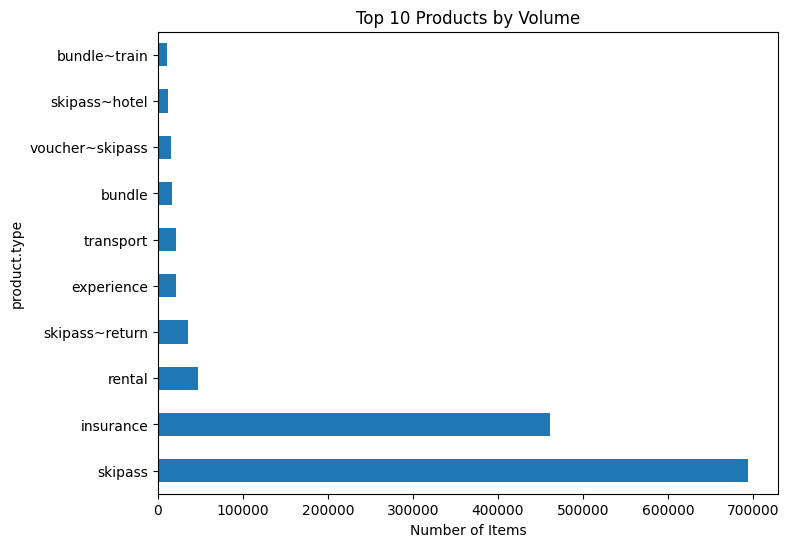

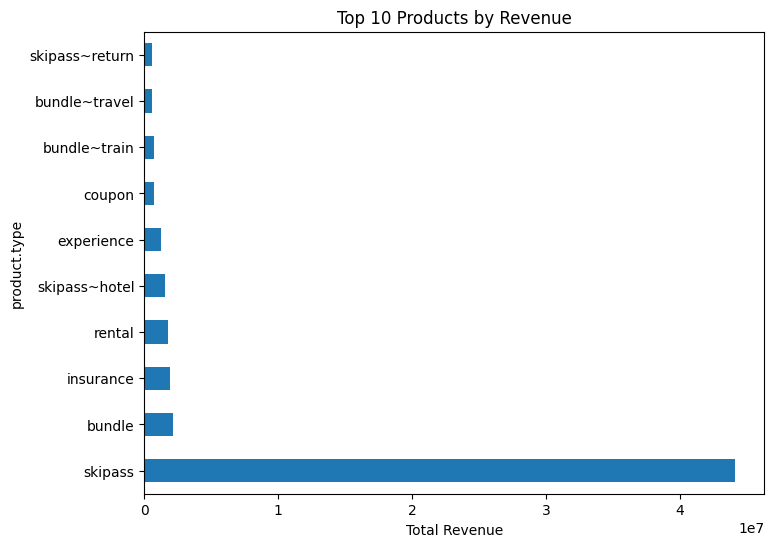

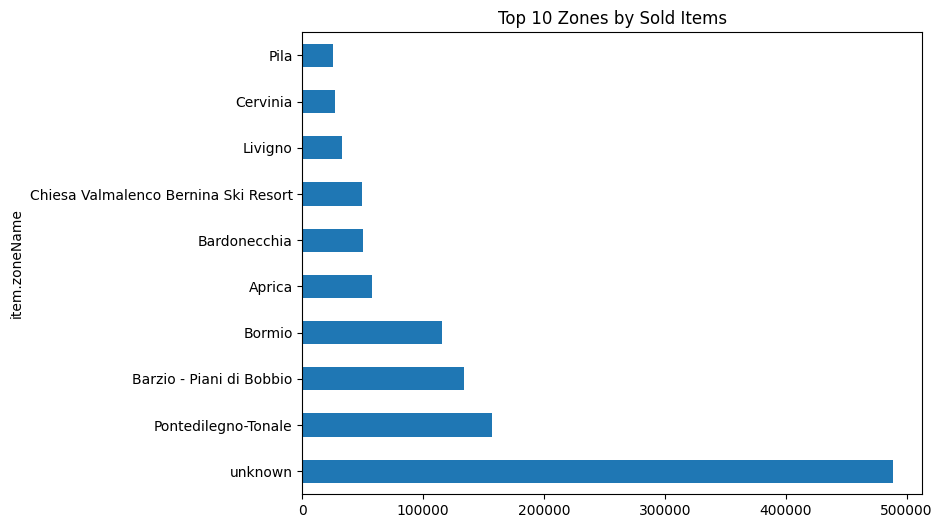

In [74]:
# top product types by volume and by revenue
top_by_volume = od.groupby("product.type").size().sort_values(ascending=False).head(20)
top_by_revenue = od.groupby("product.type")["item.amount"].sum().sort_values(ascending=False).head(20)

top_by_volume.head(10).plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Products by Volume")
plt.xlabel("Number of Items")
plt.show()

top_by_revenue.head(10).plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.show()

top_zones = od["item.zoneName"].fillna("Unknown").value_counts().head(20)
top_zones.head(10).plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Zones by Sold Items")
plt.show()


### Seasonality of products

/tmp/ipython-input-2704982946.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = od_valid_date.set_index("item.date").groupby(pd.Grouper(freq="M")).agg(


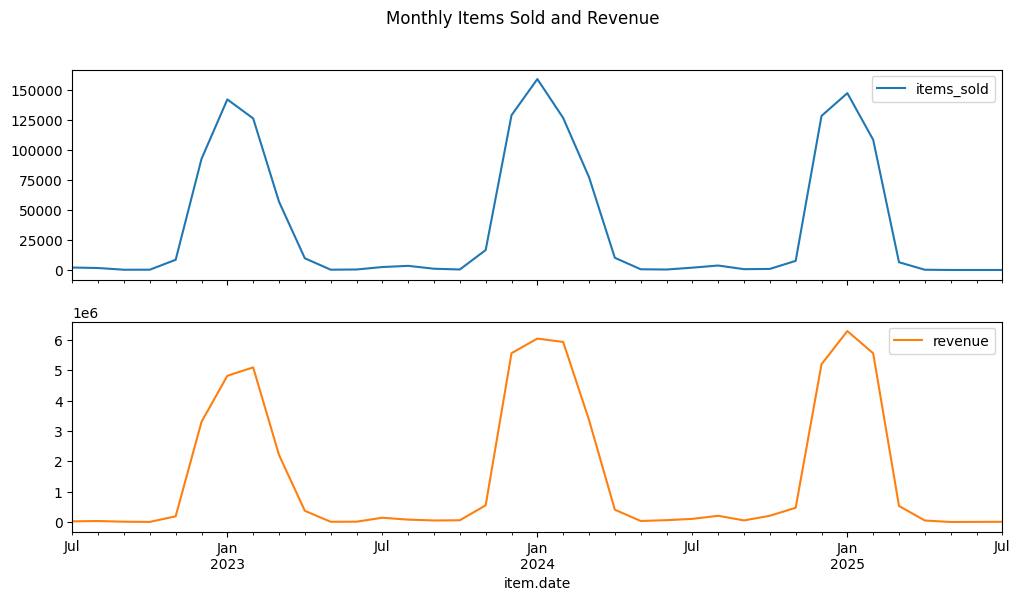

/tmp/ipython-input-2704982946.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(freq="M"), "product.type"])["item.amount"]


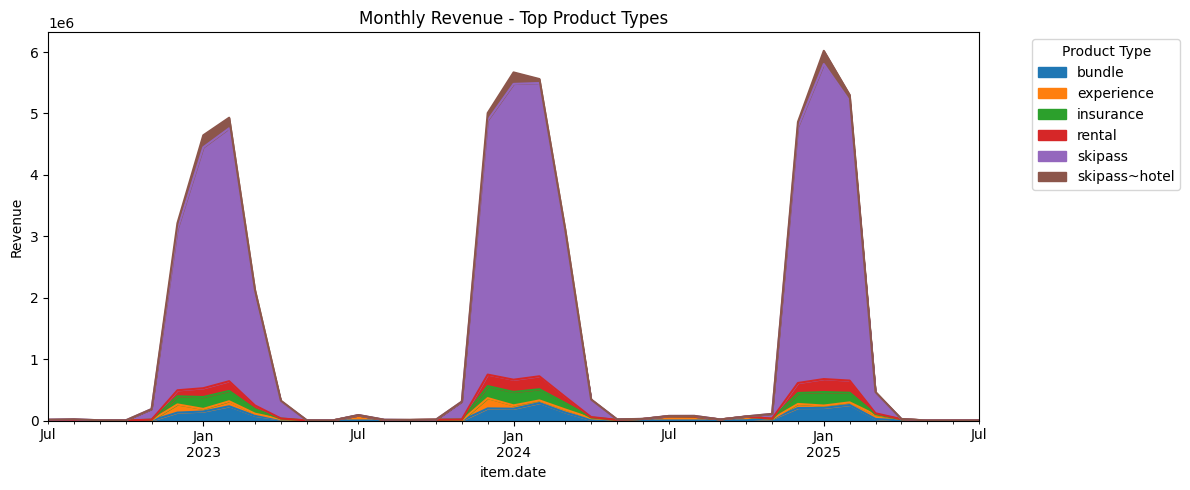

In [75]:
# ventes by month
od_valid_date = od[od["item.date"].notna()].copy()
monthly = od_valid_date.set_index("item.date").groupby(pd.Grouper(freq="M")).agg(
    items_sold = ("item.uid","count"),
    revenue = ("item.amount","sum")
)
monthly.plot(subplots=True, figsize=(12,6))
plt.suptitle("Monthly Items Sold and Revenue")
plt.show()

# Select top 6 product types by revenue
top_types = top_by_revenue.index[:6].tolist()

# Filter for top product types
df_ts = (
    od_valid_date[od_valid_date["product.type"].isin(top_types)]
    .set_index("item.date")
    .groupby([pd.Grouper(freq="M"), "product.type"])["item.amount"]
    .sum()
    .unstack(fill_value=0)
)

ax = df_ts.plot.area(figsize=(12,5))

plt.title("Monthly Revenue - Top Product Types")
plt.ylabel("Revenue")
plt.legend(title="Product Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()



### Cancellation rate and booking behavior

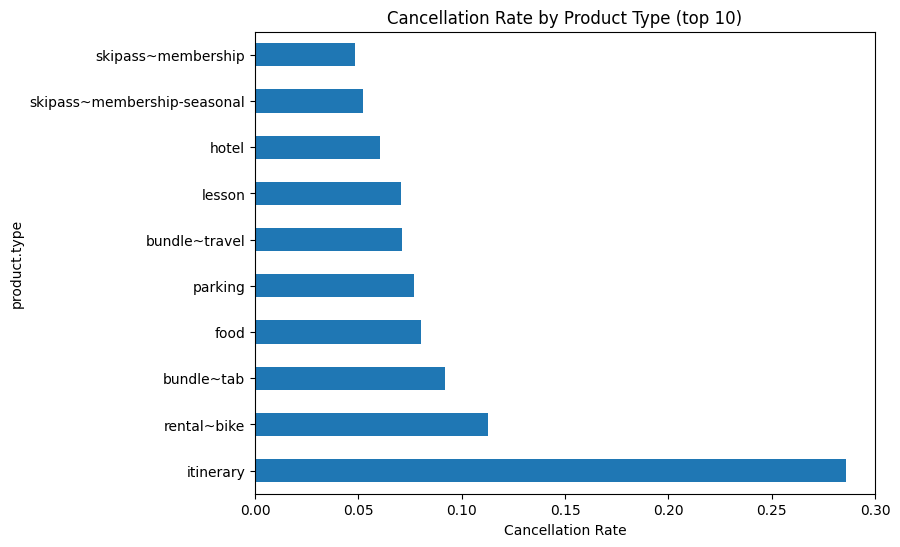

In [76]:
# item status distribution
od["item.status_norm"].value_counts(normalize=True)

# cancellation rate per product type
cancel_mask = od["item.status"].str.contains("cancel", na=False)
cancel_by_type = (cancel_mask.groupby(od["product.type"]).mean()).sort_values(ascending=False).head(10)
cancel_by_type.plot(kind="barh", figsize=(8,6))
plt.title("Cancellation Rate by Product Type (top 10)")
plt.xlabel("Cancellation Rate")
plt.show()


### Typical duration of experiences (product.durationHours)

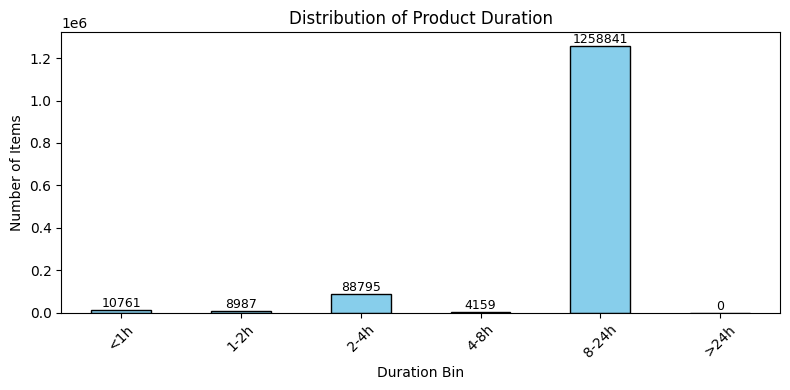

/tmp/ipython-input-379865846.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipython-input-379865846.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = df.groupby("duration_bin")["item.amount"].median()


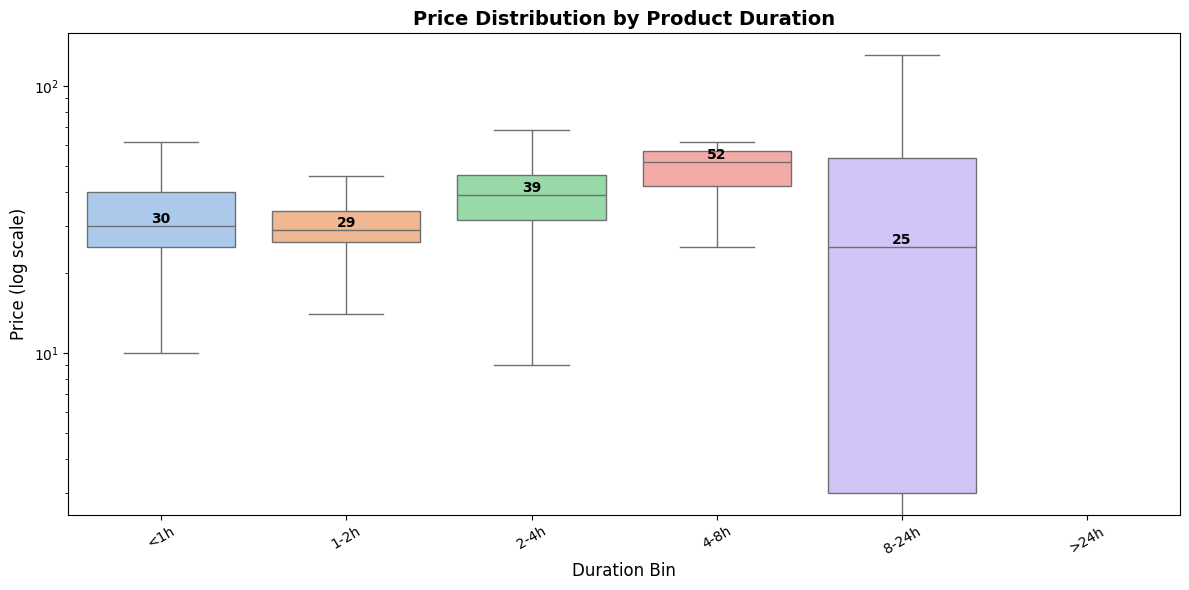

In [77]:
# Bin product duration into categories
bins = [0, 1, 2, 4, 8, 24, 1000]
labels = ["<1h", "1-2h", "2-4h", "4-8h", "8-24h", ">24h"]
od["duration_bin"] = pd.cut(od["product.durationHours"], bins=bins, labels=labels)

# Plot distribution of product duration
duration_counts = od["duration_bin"].value_counts().sort_index()

ax = duration_counts.plot(
    kind="bar", figsize=(8,4), color="skyblue", edgecolor="black"
)
plt.title("Distribution of Product Duration")
plt.xlabel("Duration Bin")
plt.ylabel("Number of Items")

# Annotate bar counts
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Filter out missing duration
df = od[od["product.durationHours"].notna()]

plt.figure(figsize=(12,6))

# Boxplot
ax = sns.boxplot(
    data=df,
    x="duration_bin",
    y="item.amount",
    palette="pastel",
    showfliers=False
)

# Set log scale to handle skewed price distributions
ax.set_yscale("log")

# Overlay median values on each box
medians = df.groupby("duration_bin")["item.amount"].median()
for i, m in enumerate(medians):
    ax.text(i, m, f'{m:.0f}', ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

plt.title("Price Distribution by Product Duration", fontsize=14, fontweight='bold')
plt.xlabel("Duration Bin", fontsize=12)
plt.ylabel("Price (log scale)", fontsize=12)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



### Co-occurence / Market Basket Analysis (simple heatmap)

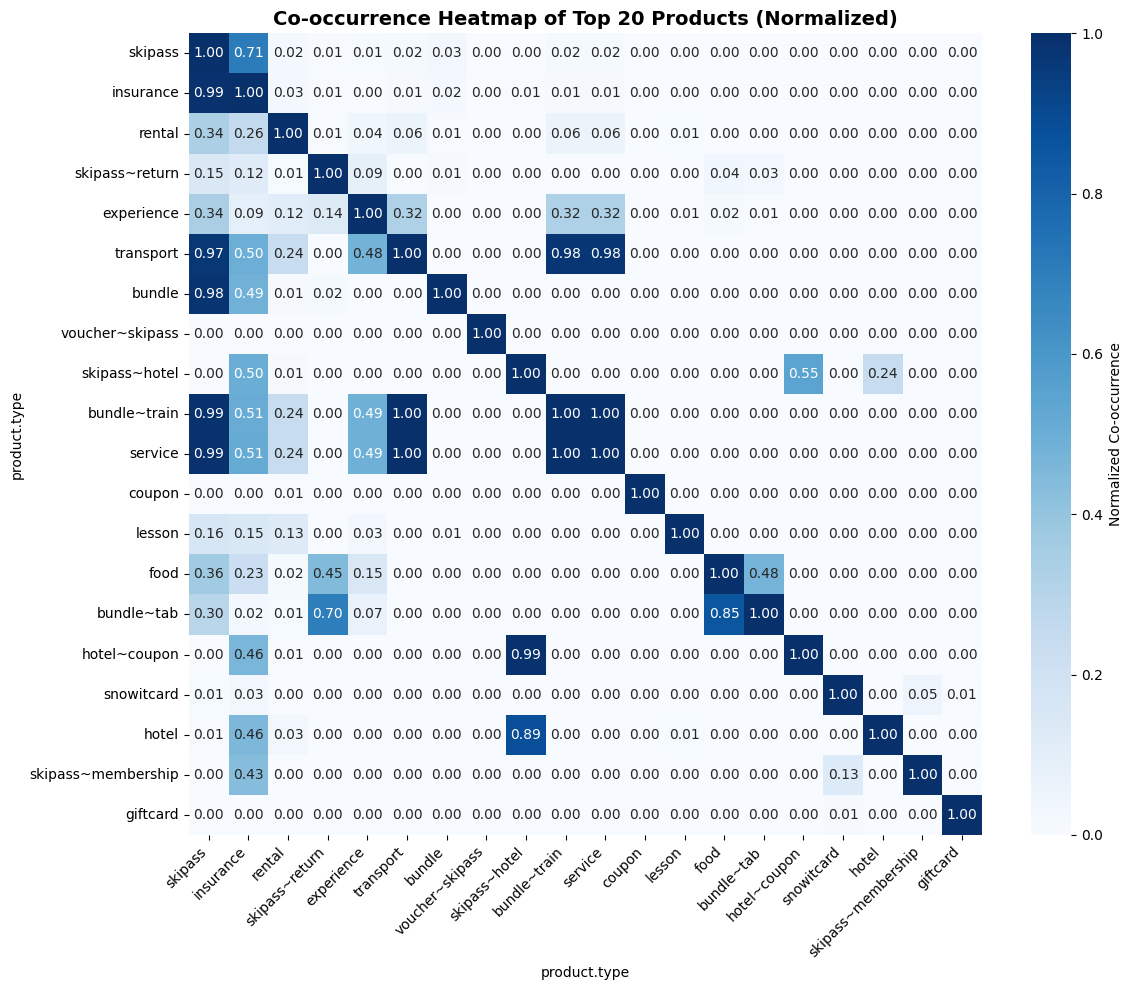

In [78]:
# Consider only fulfilled items per order
df_basket = od[fulfilled_mask].copy()

# Create pivot table: orders x product.type presence
basket = (
    df_basket.groupby(["order.uid", "product.type"])
    .size()
    .unstack(fill_value=0) > 0
).astype(int)

# Limit to top 20 products by volume for readability
top_products = top_by_volume.index[:20]
basket_top = basket[top_products]

# Compute co-occurrence counts between products
coocc = basket_top.T.dot(basket_top)

# Normalize by number of orders of each product
coocc_norm = coocc.div(np.diag(coocc), axis=0)

plt.figure(figsize=(12,10))
sns.heatmap(
    coocc_norm,
    cmap="Blues",
    xticklabels=True,
    yticklabels=True,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Normalized Co-occurrence"}
)
plt.title("Co-occurrence Heatmap of Top 20 Products (Normalized)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### Basket Size

count    525357.000000
mean          2.610688
std           2.165342
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         208.000000
Name: item.uid, dtype: float64


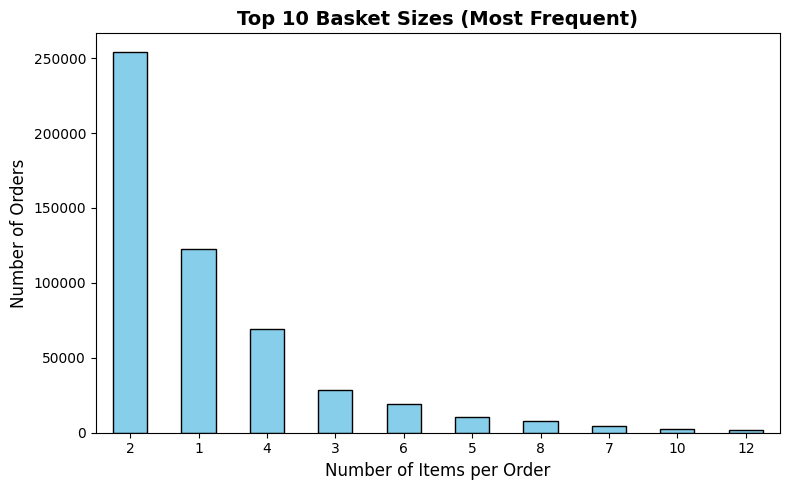

Orders with more than 1 item: 76.69%


In [79]:
# Calculate number of items per order
basket_size = od.groupby("order.uid")["item.uid"].count()

# Summary statistics
print(basket_size.describe())

# Get Top 10 most common basket sizes
basket_counts = basket_size.value_counts().head(10)

basket_counts.plot(
    kind="bar",
    figsize=(8,5),
    color="skyblue",
    edgecolor="black"
)
plt.title("Top 10 Basket Sizes (Most Frequent)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Items per Order", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Compute share of multi-item orders
multi_item_rate = (basket_size > 1).mean()
print(f"Orders with more than 1 item: {multi_item_rate:.2%}")


### Seasonality by Product Type

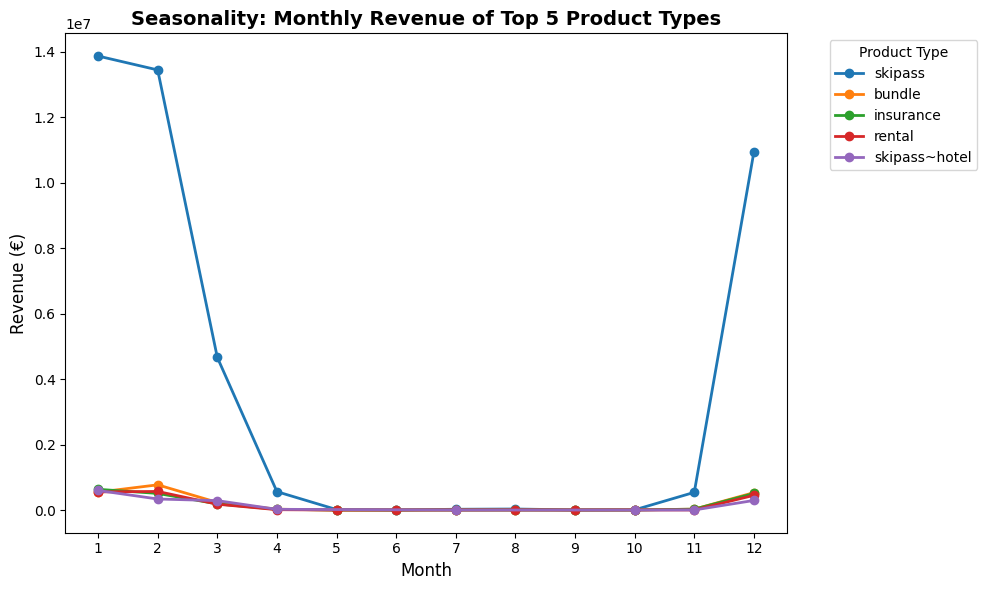

In [80]:
# Extract month from item.date
od_valid_date["month"] = od_valid_date["item.date"].dt.month

# Aggregate monthly revenue per product type
seasonality = od_valid_date.groupby(["month","product.type"])["item.amount"].sum().reset_index()

# Select Top 5 product types by total revenue
top5_types = seasonality.groupby("product.type")["item.amount"].sum().nlargest(5).index
seasonality_top5 = seasonality[seasonality["product.type"].isin(top5_types)]

# Plot seasonality trends
plt.figure(figsize=(10,6))
for p in top5_types:
    subset = seasonality_top5[seasonality_top5["product.type"] == p]
    plt.plot(
        subset["month"], subset["item.amount"], marker="o", linewidth=2, label=p
    )

plt.title("Seasonality: Monthly Revenue of Top 5 Product Types", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue (€)", fontsize=12)
plt.xticks(range(1,13))
plt.legend(title="Product Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### KPI

In [81]:
od["item.date"] = pd.to_datetime(od["item.date"], errors="coerce")

# KPIs
total_items = len(od)
total_orders = od["order.uid"].nunique()
total_products = od["product.uid"].nunique()

# Sales metrics
total_amount = od["item.amount"].sum()
avg_amount_per_item = od["item.amount"].mean()

# Discounts
total_discount = od["item.discount"].sum()
avg_discount_rate = (od["item.discount"] / (od["item.amount"] + od["item.discount"])).mean()

# Dynamic pricing usage
dynamic_pricing_rate = od["product.dynamicPricing"].mean()

# Product mix
product_type_dist = od["product.type"].value_counts(normalize=True).round(3) * 100

# Zone distribution (Top 5)
zone_top = od["item.zoneName"].value_counts(normalize=True).head(5).round(3) * 100

# Duration analysis
avg_duration = od["product.durationHours"].mean()
max_duration = od["product.durationHours"].max()

# Snowit Card usage
snowitcard_rate = od["item.snowitcardNumber"].notna().mean()

# Item status
status_dist = od["item.status"].value_counts(normalize=True).round(3) * 100

# Time trend
items_per_month = od["item.date"].dt.to_period("M").value_counts().sort_index()

# Print Dashboard
print("===== ORDER_DETAILS KPI DASHBOARD =====\n")
print(f"Total Items: {total_items:,}")
print(f"Total Orders Linked: {total_orders:,}")
print(f"Unique Products: {total_products:,}\n")

print(f"Total Sales Amount: €{total_amount:,.2f}")
print(f"Average Amount per Item: €{avg_amount_per_item:.2f}\n")

print(f"Total Discount Given: €{total_discount:,.2f}")
print(f"Average Discount Rate: {avg_discount_rate:.2%}\n")

print(f"Dynamic Pricing Usage: {dynamic_pricing_rate:.2%}\n")

print("Product Type Distribution (%):")
print(product_type_dist, "\n")

print("Top 5 Zones by Orders (%):")
print(zone_top, "\n")

print(f"Average Product Duration: {avg_duration:.2f} hours")
print(f"Max Product Duration: {max_duration} hours\n")

print(f"Orders with SnowitCard: {snowitcard_rate:.2%}\n")

print("Item Status Distribution (%):")
print(status_dist, "\n")

print("Items per Month:")
print(items_per_month)


===== ORDER_DETAILS KPI DASHBOARD =====

Total Items: 1,371,543
Total Orders Linked: 525,357
Unique Products: 9,045

Total Sales Amount: €56,980,419.61
Average Amount per Item: €41.54

Total Discount Given: €244,833.00
Average Discount Rate: 0.42%

Dynamic Pricing Usage: 18.78%

Product Type Distribution (%):
product.type
skipass                        50.7
insurance                      33.7
rental                          3.5
skipass~return                  2.6
experience                      1.6
transport                       1.5
bundle                          1.2
voucher~skipass                 1.1
skipass~hotel                   0.8
bundle~train                    0.8
service                         0.8
coupon                          0.4
lesson                          0.3
food                            0.2
bundle~tab                      0.2
hotel~coupon                    0.2
snowitcard                      0.1
hotel                           0.1
skipass~membership          

# Data understanding

In [82]:
# Unique users who have placed at least one order vs total registered users
unique_order_users = orders['user.uid'].nunique()
total_users = len(users)
print(unique_order_users, total_users)

# Orders that have detailed items in the order details
orders_in_od = set(orders['order.uid']) & set(od['order.uid'])
print("Orders with details:", len(orders_in_od))

# Number of profiles and cards per user
profiles_per_user = profiles.groupby('user.uid').size()
cards_per_user = cards.groupby('user.uid').size()

# Summary statistics for profiles and cards per user
print(profiles_per_user.describe())
print(cards_per_user.describe())



231564 715839
Orders with details: 524564
count    64238.000000
mean         1.512469
std          1.200209
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         84.000000
dtype: float64
count    145227.000000
mean          2.087442
std           2.100544
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max         416.000000
dtype: float64


In [83]:
# Orders that have corresponding details in the ORDER_DETAILS table
orders_in_od = set(orders['order.uid']) & set(od['order.uid'])
print("Orders with details:", len(orders_in_od))



Orders with details: 524564


In [84]:
#  Users in ORDERS that also exist in USERS
users_in_orders = set(users['user.uid'])
orders_users = set(orders['user.uid'])
common_users = users_in_orders & orders_users
print("Users in orders:", len(common_users))

# Orders with user IDs that are missing in USERS table
missing_users = orders_users - users_in_orders
print("Missing users in orders:", len(missing_users))



Users in orders: 160178
Missing users in orders: 71386


In [85]:
# Number of profiles per user
profiles_per_user = profiles.groupby('user.uid').size()
print("Profiles per user summary:")
print(profiles_per_user.describe())

# Number of cards per user
cards_per_user = cards.groupby('user.uid').size()
print("Cards per user summary:")
print(cards_per_user.describe())



Profiles per user summary:
count    64238.000000
mean         1.512469
std          1.200209
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         84.000000
dtype: float64
Cards per user summary:
count    145227.000000
mean          2.087442
std           2.100544
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max         416.000000
dtype: float64


In [86]:
# Merge order_details with orders
df = od.merge(
    orders[['order.uid', 'user.uid', 'createdAt']],
    on='order.uid',
    how='left'
)

df['createdAt'] = pd.to_datetime(df['createdAt'], errors='coerce')

# 2023-2024 Season: from November 1, 2023 to April 30, 2024
season_start = pd.Timestamp(year=2023, month=11, day=1)
season_end   = pd.Timestamp(year=2024, month=4, day=30)

df_season = df[(df['createdAt'] >= season_start) & (df['createdAt'] <= season_end)]

# Sum of the amounts per order
order_totals = df_season.groupby('order.uid')['item.amount'].sum().reset_index(name='order_total')

# AOV = average order totals
AOV = order_totals['order_total'].mean()
print(f"Average Order Value (AOV): €{AOV:.2f}")

# Total spent per user
user_spent = df_season.groupby('user.uid')['item.amount'].sum().reset_index(name='total_spent')

# Number of unique users
num_users = df_season['user.uid'].nunique()

# Average spending per user
avg_spent_per_user = user_spent['total_spent'].mean()
print(f"Average spending per user in the season: €{avg_spent_per_user:.2f}")


Average Order Value (AOV): €109.49
Average spending per user in the season: €223.46


In [87]:

def get_season(date):
    if pd.isna(date):
        return None
    year = date.year
    if date.month in [11, 12]:
        return f"{year}-{year+1}"
    elif date.month in [1, 2, 3, 4]:
        return f"{year-1}-{year}"
    else:
        return None

orders['season'] = orders['createdAt'].map(get_season)

# Active for each season
active_by_season = (
    orders.groupby('season')['user.uid']
    .nunique()
    .reset_index(name='active_users')
    .sort_values('season')
)

print("Active users per season:")
print(active_by_season)

users_2324 = set(orders.loc[orders['season'] == "2023-2024", "user.uid"])
users_2425 = set(orders.loc[orders['season'] == "2024-2025", "user.uid"])

n_prev = len(users_2324)
n_retained = len(users_2324 & users_2425)
n_churned = n_prev - n_retained
churn_rate = n_churned / n_prev if n_prev > 0 else 0

print(f"\nUsers active in 2024/25 season: {len(users_2425)}")
print(f"Churn rate 2023/24 → 2024/25: {churn_rate:.2%}")


Active users per season:
      season  active_users
0  2022-2023         82335
1  2023-2024         96655
2  2024-2025        106139

Users active in 2024/25 season: 106139
Churn rate 2023/24 → 2024/25: 70.36%


# RFM

In [88]:
# Filter only valid orders based on item status
valid_status = ["ok", "fulfilled", "on-hold"]
order_details_valid = od[od["item.status"].isin(valid_status)]

# Compute total amount per order (sum of valid item amounts)
order_amounts = (
    order_details_valid
    .groupby("order.uid", as_index=False)
    .agg({"item.amount": "sum"})
    .rename(columns={"item.amount": "totalAmount"})
)

# Merge total order amount into orders
orders_valid = (
    orders.merge(order_amounts, on="order.uid", how="inner")
)

# Join orders with user information
orders_users = (
    orders_valid
    .merge(users, on="user.uid", how="left")
)

# Data checks
print("Total initial orders:", len(orders))
print("Total valid orders:", len(orders_valid))
print("Total unique users with at least 1 valid order:", orders_users["user.uid"].nunique())

# Preview merged dataframe
orders_users.head()


Total initial orders: 549105
Total valid orders: 519974
Total unique users with at least 1 valid order: 218375


,order.uid,user.uid,createdAt_x,createdAtTime,paymentGateway,paymentBrand,pickup,pickupComplete,source_x,tenant,...,hour,season,totalAmount,createdAt_y,source_y,isAnonymous,referralsCount,city,language,signup_provider
0,4y9zqqvldfqr9n2xnu,nu7fhz41rzwbkabapcufr6g18r,2024-07-01,2024-07-01 19:41:44,stripe,visa,False,False,website,snowit_esterno,...,19,None,59.5,2021-01-18,website,False,0.0,Giussano,it,google
1,termljwsr2gecnzwks,ghol7lwjlhewwvasejlxa9fv00,2024-07-01,2024-07-01 18:34:12,discount,unknown,False,False,website,snowit_esterno,...,18,None,0.0,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,tu8b9haokkimu72aza,oyekz0wyxcplvrpencpuue6sdt,2024-07-01,2024-07-01 16:02:11,stripe,mastercard,False,False,website,snowit_esterno,...,16,None,122.5,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,a8mvwuv6ileh9aqblu,1p0ocryxz4ts2wtsi1bawtjndt,2024-07-01,2024-07-01 15:46:12,stripe,unknown,False,False,website,tribala,...,15,None,60.0,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,i9eovtgp3uxbmesebv,hkxsbgefntzwsodvj3ztvp3gm1,2024-07-01,2024-07-01 08:56:34,discount,unknown,False,False,website,discovera,...,8,None,100.0,2024-05-06,website,False,0.0,Milano,it,unknown


In [89]:
# Columns check
orders_users.columns

Index(['order.uid', 'user.uid', 'createdAt_x', 'createdAtTime',
       'paymentGateway', 'paymentBrand', 'pickup', 'pickupComplete',
       'source_x', 'tenant', 'paymentAttempts', 'timeZone', 'clientInfo',
       'weekday', 'hour', 'season', 'totalAmount', 'createdAt_y', 'source_y',
       'isAnonymous', 'referralsCount', 'city', 'language', 'signup_provider'],
      dtype='object')

Min order date: 2022-07-01 00:00:00
Max order date: 2025-02-15 00:00:00
Reference date (for Recency): 2025-02-15 00:00:00

RFM head:
                      user.uid  Recency  Frequency  Monetary  R_score  F_score  \
0  000efwkhjsrdky4apdueq3itig      750          1    132.00        1        1   
1  000shjpcfnwj961oiepqfq5kkx        0         23   1052.50        4        4   
2  001vktlc5zbkx2bazqkwmrpru9       73          1    162.15        3        1   
3  002cjigqy3zbbtaehc5a7f0iod      735          1    150.00        1        1   
4  002mevswzwathpgi77wgfjx3yf      401          1    525.00        2        1   

   M_score RFM_code  RFM_sum                 Segment  
0        3      113        5                    Lost  
1        4      444       12               Champions  
2        3      313        7  Low Value / Occasional  
3        3      113        5                    Lost  
4        4      214        7            Big Spenders  

RFM descriptive stats:
              Recency    

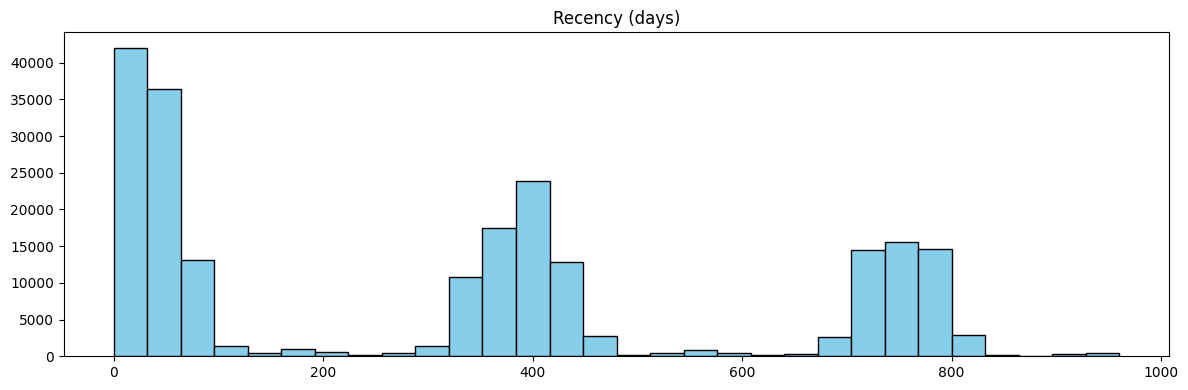

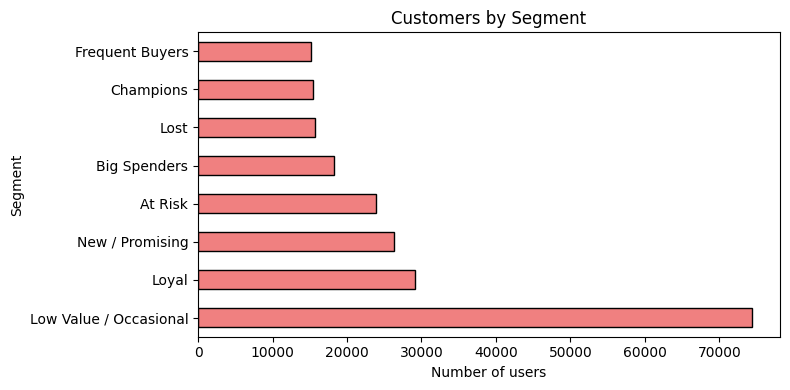


Top 10 customers by Monetary:
                           user.uid   Monetary  Frequency  Recency RFM_code  \
111134  kuo6uveetwuw8hv1o6j6vms4dz  235173.50        195      391      244   
178569  ugtgazpkmbwhw6n3xpw0ieuqb5   59613.73         75       12      444   
189453  vxhjq1lwluoo2padxcj6ir3wpw   49575.00         78      761      144   
198294  xatxibhhako9fsca1addtksffp   43587.70         81        2      444   
25153   7agcvnyl3gbpcb7ipfllue1fg1   35602.50         62        6      444   
211932  z6hknmlvogeceqorqomikjrjkq   30302.60         27      191      344   
167956  sx9b6kbq2kmv5bjf9s1mbphbug   28460.00         25        7      444   
132399  nv0v0zabfjnzs7gkzbccngohrz   18288.90          4       28      444   
177829  udrlwuczecd4dwzszzgt9muyuw   17668.93         12       22      444   
95783   ioqipshlwme6doixe7wex1mcjz   13868.00          9        8      444   

          Segment  
111134      Loyal  
178569  Champions  
189453      Loyal  
198294  Champions  
25153   C

In [90]:
# Ensure date columns are datetime
orders_users["createdAt_x"] = pd.to_datetime(orders_users["createdAt_x"], errors="coerce")  # order date
orders_users["createdAt_y"] = pd.to_datetime(orders_users["createdAt_y"], errors="coerce")  # user creation date (optional)

print("Min order date:", orders_users["createdAt_x"].min())
print("Max order date:", orders_users["createdAt_x"].max())

# Reference date for Recency calculation
reference_date = orders_users["createdAt_x"].max()
print("Reference date (for Recency):", reference_date)

# Build RFM table
rfm = (
    orders_users
    .groupby("user.uid", as_index=True)
    .agg(
        Recency=("createdAt_x", lambda x: (reference_date - x.max()).days),  # days since last order
        Frequency=("order.uid", "nunique"),  # number of orders
        Monetary=("totalAmount", "sum")  # total spending
    )
)
rfm["Monetary"] = rfm["Monetary"].fillna(0.0)
rfm = rfm.reset_index()

# Score R, F, M on a 1..4 scale using quartiles
# Recency: more recent = higher score
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1]).astype(int)
# Frequency: more orders = higher score
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
# Monetary: more spending = higher score
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)

# Combine RFM scores
rfm["RFM_code"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm["RFM_sum"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

# Deterministic segmentation based on scores
def rfm_segment_expert(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']

    # Champions: top in all dimensions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    # Loyal: top in at least 2 dimensions
    elif (r >= 4 and f >= 4) or (f >= 4 and m >= 4) or (r >= 4 and m >= 4):
        return "Loyal"
    # Big Spenders: high spenders even if not recent/frequent
    elif m >= 4:
        return "Big Spenders"
    # Frequent Buyers: buy often
    elif f >= 4:
        return "Frequent Buyers"
    # New / Promising: recent buyers
    elif r >= 4:
        return "New / Promising"
    # At Risk: not recent but previously active
    elif r <= 2 and f >= 3:
        return "At Risk"
    # Lost: long inactive and low frequency
    elif r == 1 and f == 1:
        return "Lost"
    # Low Value / Occasional: all others
    else:
        return "Low Value / Occasional"

rfm["Segment"] = rfm.apply(rfm_segment_expert, axis=1)

# Summary statistics
print("\nRFM head:\n", rfm.head())
print("\nRFM descriptive stats:\n", rfm[["Recency","Frequency","Monetary","R_score","F_score","M_score","RFM_sum"]].describe())

segment_counts = rfm["Segment"].value_counts().rename_axis("Segment").reset_index(name="Count")
print("\nCounts by Segment:\n", segment_counts)

rfm.to_csv("rfm_customers_quartiles.csv", index=False)
print("\nRFM saved to rfm_customers_quartiles.csv")

# Histogram for RFM
plt.figure(figsize=(12,4))
plt.hist(rfm["Recency"], bins=30, color='skyblue', edgecolor='black')
plt.title("Recency (days)")
plt.tight_layout()
plt.show()

# Bar chart for segments
plt.figure(figsize=(8,4))
rfm["Segment"].value_counts().plot(kind="barh", color='lightcoral', edgecolor='black')
plt.title("Customers by Segment")
plt.xlabel("Number of users")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

# Top 10 customers by monetary
top10 = rfm.sort_values("Monetary", ascending=False).head(10)
print("\nTop 10 customers by Monetary:\n", top10[["user.uid","Monetary","Frequency","Recency","RFM_code","Segment"]])


### RFM Segment Comparison: Customer Share vs Revenue Share

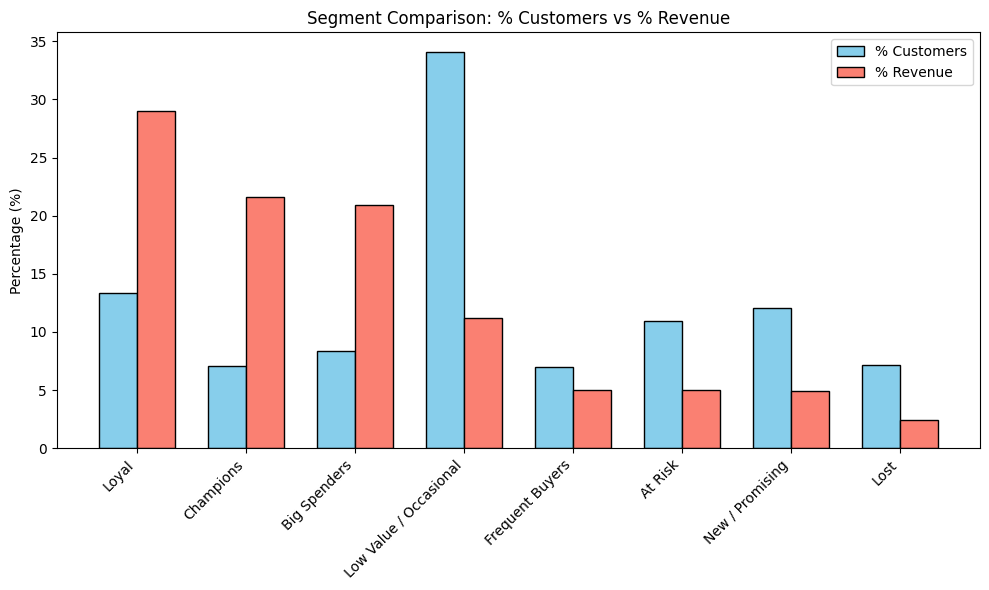

In [91]:
# Compute segment-level metrics
segment_summary = rfm.groupby("Segment").agg(
    customer_count=("user.uid", "count"),
    revenue=("Monetary", "sum")
).sort_values("revenue", ascending=False)

# Compute percentages
segment_summary["%Customers"] = 100 * segment_summary["customer_count"] / segment_summary["customer_count"].sum()
segment_summary["%Revenue"] = 100 * segment_summary["revenue"] / segment_summary["revenue"].sum()

# Plot side-by-side bar chart
plt.figure(figsize=(10,6))
width = 0.35
x = np.arange(len(segment_summary))

plt.bar(x - width/2, segment_summary["%Customers"], width=width, label="% Customers", color="skyblue", edgecolor="black")
plt.bar(x + width/2, segment_summary["%Revenue"], width=width, label="% Revenue", color="salmon", edgecolor="black")

plt.xticks(x, segment_summary.index, rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.title("Segment Comparison: % Customers vs % Revenue")
plt.legend()
plt.tight_layout()
plt.show()


# CHURN PREDICTION MODEL

### Creation of dataset with churn taking into account seasonal cutoff

In [92]:
# Constants
CHURN_DAYS = 180
SEASON_START = 11  # from November
SEASON_END = 4     # to April
REFERENCE_DATE = None

USER_KEY = 'user.uid'
ORDER_KEY = 'order.uid'

# Functions
def try_parse(obj):
    if isinstance(obj, (dict, list)):
        return obj
    if pd.isna(obj):
        return None
    s = str(obj)
    try:
        return ast.literal_eval(s)
    except Exception:
        try:
            return json.loads(s)
        except Exception:
            return s

def find_col(df, name, loose=False):
    if name in df.columns:
        return name
    cutoff = 0.6 if not loose else 0.3
    matches = difflib.get_close_matches(name, df.columns, n=1, cutoff=cutoff)
    return matches[0] if matches else None

# Ensure datetime format
orders['createdAt'] = pd.to_datetime(orders['createdAt'], errors='coerce')

# Compute reference date: end of previous season
last_order_date = orders['createdAt'].max()
if last_order_date.month >= SEASON_START:
    REFERENCE_DATE = pd.Timestamp(year=last_order_date.year, month=SEASON_END, day=30)
else:
    REFERENCE_DATE = pd.Timestamp(year=last_order_date.year-1, month=SEASON_END, day=30)

print('Reference date (end of previous season):', REFERENCE_DATE)

# Clean column names
for df in [orders, od, users, profiles, cards]:
    df.columns = df.columns.str.strip()

# Identify key columns
order_col_od     = find_col(od, ORDER_KEY)
order_col_orders = find_col(orders, ORDER_KEY)
user_col_orders  = find_col(orders, USER_KEY)

# Loose fallback search
if order_col_od is None: order_col_od = find_col(od, ORDER_KEY, loose=True)
if order_col_orders is None: order_col_orders = find_col(orders, ORDER_KEY, loose=True)
if user_col_orders is None: user_col_orders = find_col(orders, USER_KEY, loose=True)

if None in [order_col_od, order_col_orders, user_col_orders]:
    raise KeyError("Key columns not found in the datasets!")

# Standardize key column names
od2 = od.rename(columns={order_col_od: ORDER_KEY})
orders2 = orders.rename(columns={order_col_orders: ORDER_KEY, user_col_orders: USER_KEY})

# Filter orders up to reference date
orders_cutoff = orders2.loc[
    orders2['createdAt'] <= REFERENCE_DATE,
    [ORDER_KEY, USER_KEY, 'createdAt', 'source', 'tenant', 'pickup', 'pickupComplete', 'paymentGateway']
].copy()

# Merge order details with filtered orders
od_cutoff = od2.merge(orders_cutoff, on=ORDER_KEY, how='left', suffixes=('', '_ord'))

# Ensure USER_KEY is present
if USER_KEY not in od_cutoff.columns or od_cutoff[USER_KEY].isna().all():
    order2user = orders_cutoff.set_index(ORDER_KEY)[USER_KEY].to_dict()
    od_cutoff[USER_KEY] = od_cutoff[ORDER_KEY].map(order2user)

# Remove duplicated columns
od_cutoff = od_cutoff.loc[:, ~od_cutoff.columns.duplicated()]

# Additional features
od_cutoff['line_value'] = od_cutoff['item.amount'].fillna(0.0).astype(np.float32)
od_cutoff['is_dynamic_pricing'] = od_cutoff['product.dynamicPricing'].fillna(False).astype(np.int8)
od_cutoff['has_discount'] = od_cutoff['item.discount'].fillna(False).astype(np.int8)

# Aggregate per user
agg1 = od_cutoff.groupby(USER_KEY).agg(
    total_items=('item.uid', 'count'),
    total_fulfilled_items=('item.status', lambda x: (x.isin(['ok','fulfilled'])).sum()),
    sum_amount=('line_value', 'sum'),
    avg_amount=('line_value', 'mean'),
    dynamic_count=('is_dynamic_pricing', 'sum'),
    discount_count=('has_discount', 'sum'),
    unique_zones=('item.zoneName','nunique'),
    unique_products=('product.uid','nunique'),
    avg_duration_hours=('product.durationHours','mean')
).reset_index()

# Orders summary per user
orders_user = orders_cutoff.groupby(USER_KEY).agg(
    order_count=('order.uid','nunique'),
    first_order=('createdAt','min'),
    last_order=('createdAt','max')
).reset_index()
orders_user = orders_user.merge(agg1, on=USER_KEY, how='left')

# Fill missing numeric values with 0
num_cols = ['sum_amount','avg_amount','dynamic_count','discount_count',
            'unique_zones','unique_products','avg_duration_hours',
            'total_items','total_fulfilled_items']
orders_user[num_cols] = orders_user[num_cols].fillna(0)

# Recency, tenure, and orders per month
orders_user['recency_days'] = (REFERENCE_DATE - orders_user['last_order']).dt.days
orders_user['tenure_days'] = (orders_user['last_order'] - orders_user['first_order']).dt.days.fillna(0)
orders_user['orders_per_month'] = orders_user['order_count'] / (orders_user['tenure_days'].replace(0,30)/30.0)

# Profile aggregates
profiles['birthday'] = pd.to_datetime(profiles['birthday'], errors='coerce')
profiles['age'] = (REFERENCE_DATE - profiles['birthday']).dt.days / 365.25

prof_count = profiles.groupby(USER_KEY).size().rename('profiles_count')
avg_age = profiles.groupby(USER_KEY)['age'].mean().rename('avg_profile_age')
sex_mode = profiles.groupby(USER_KEY).apply(lambda g: (g['sex']=='male').mean()).rename('pct_male')
prof_agg = pd.concat([prof_count, avg_age, sex_mode], axis=1).reset_index()

# Cards aggregates
cards['assignedAt'] = pd.to_datetime(cards['assignedAt'], errors='coerce')
cards['assigned_age_days'] = (REFERENCE_DATE - cards['assignedAt']).dt.days

card_status_counts = cards.pivot_table(
    index=USER_KEY, columns='status', values='card.uid',
    aggfunc='nunique', fill_value=0
).reset_index()
card_counts = cards.groupby(USER_KEY).size().reset_index(name='cards_count')

# Users clean
# Keep only relevant columns and robust to missing ones
columns_to_keep = [
    USER_KEY, 'createdAt', 'source', 'city', 'language', 'referralsCount',
    'isAnonymous', 'signup_provider'
]
users_clean = users[[c for c in columns_to_keep if c in users.columns]].copy()

# Fill boolean safely
if 'isAnonymous' in users_clean.columns:
    users_clean['isAnonymous'] = users_clean['isAnonymous'].fillna(False).astype(np.int8)

# Merge all data
df = users_clean.copy()
df = df.merge(orders_user, on=USER_KEY, how='left')
df = df.merge(prof_agg, on=USER_KEY, how='left')
df = df.merge(card_counts, on=USER_KEY, how='left')
df = df.merge(card_status_counts, on=USER_KEY, how='left')

# Fill numeric NaNs with 0
for c in df.select_dtypes(include=[np.number]).columns:
    df[c] = df[c].fillna(0).astype(np.float32)

# Average spend per order
if 'sum_amount' in df.columns and 'order_count' in df.columns:
    df['avg_spend_per_order'] = np.where(df['order_count']>0,
                                         df['sum_amount']/df['order_count'], 0)

# Seasonal churn label
season_start_prev = pd.Timestamp(year=REFERENCE_DATE.year-1, month=SEASON_START, day=1)
season_end_prev   = REFERENCE_DATE

orders_prev_season = orders2[(orders2['createdAt'] >= season_start_prev) &
                             (orders2['createdAt'] <= season_end_prev)]
users_prev_set = set(orders_prev_season[USER_KEY].unique())

season_start_next = pd.Timestamp(year=REFERENCE_DATE.year if REFERENCE_DATE.month < 12 else REFERENCE_DATE.year+1,
                                 month=SEASON_START, day=1)
season_end_next = pd.Timestamp(year=REFERENCE_DATE.year+1, month=SEASON_END, day=30)

orders_next_season = orders2[(orders2['createdAt'] >= season_start_next) &
                             (orders2['createdAt'] <= season_end_next)]
users_next_set = set(orders_next_season[USER_KEY].unique())

df['churn'] = np.where(df[USER_KEY].isin(users_prev_set),
                       np.where(df[USER_KEY].isin(users_next_set), 0, 1),
                       np.nan)

# Keep only users with churn info
df = df[df['churn'].notna()].copy()
df['churn'] = df['churn'].astype(np.int8)

print('Final dataset shape:', df.shape)
print('Churn distribution:\n', df['churn'].value_counts(normalize=True))


Reference date (end of previous season): 2024-04-30 00:00:00


/tmp/ipython-input-2103922576.py:125: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sex_mode = profiles.groupby(USER_KEY).apply(lambda g: (g['sex']=='male').mean()).rename('pct_male')


Final dataset shape: (68646, 34)
Churn distribution:
 churn
1    0.706465
0    0.293535
Name: proportion, dtype: float64


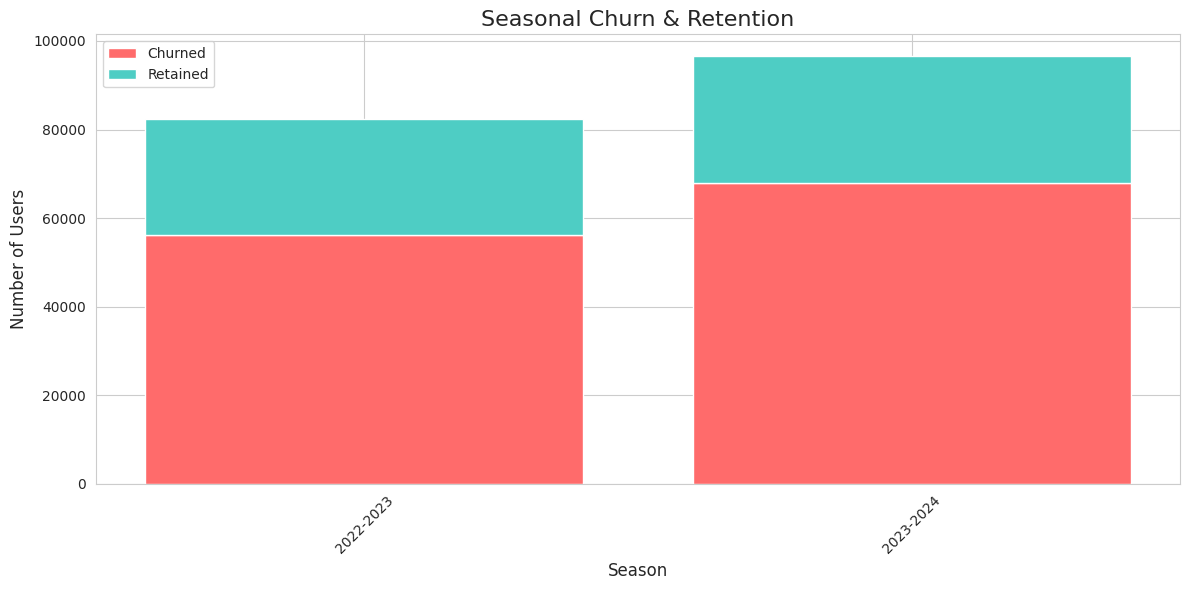

,season,active_users,retained,churned,churn_rate
0,2022-2023,82335,26183,56152,0.681994
1,2023-2024,96655,28649,68006,0.703595


In [93]:
# Function to assign season
def get_season(date):
    if pd.isna(date):
        return None
    year = date.year
    if date.month in [11, 12]:
        return f"{year}-{year+1}"
    elif date.month in [1, 2, 3, 4]:
        return f"{year-1}-{year}"
    else:
        return None

# Apply season label to orders
orders['season'] = orders['createdAt'].map(get_season)

# Active users per season
active_by_season = orders.groupby('season')[USER_KEY].nunique().reset_index(name='active_users')

# Calculate seasonal churn
churn_stats = []
seasons_sorted = sorted([s for s in active_by_season['season'].dropna().unique()])

for i in range(len(seasons_sorted) - 1):
    prev_season = seasons_sorted[i]
    next_season = seasons_sorted[i + 1]

    users_prev = set(orders.loc[orders['season'] == prev_season, USER_KEY])
    users_next = set(orders.loc[orders['season'] == next_season, USER_KEY])

    n_prev = len(users_prev)
    n_retained = len(users_prev & users_next)
    n_churn = n_prev - n_retained
    churn_rate = n_churn / n_prev if n_prev > 0 else 0

    churn_stats.append({
        'season': prev_season,
        'active_users': n_prev,
        'retained': n_retained,
        'churned': n_churn,
        'churn_rate': churn_rate
    })

churn_df = pd.DataFrame(churn_stats)

sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

plt.bar(churn_df['season'], churn_df['churned'], label='Churned', color='#FF6B6B')
plt.bar(churn_df['season'], churn_df['retained'], bottom=churn_df['churned'], label='Retained', color='#4ECDC4')

plt.title("Seasonal Churn & Retention", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

churn_df


### churn standard

Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.854436	valid_1's auc: 0.823325
Early stopping, best iteration is:
[34]	training's auc: 0.844952	valid_1's auc: 0.824022
ROC AUC: 0.8240
PR AUC: 0.9179
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.77      0.63      4030
           1       0.88      0.72      0.79      9700

    accuracy                           0.74     13730
   macro avg       0.71      0.75      0.71     13730
weighted avg       0.78      0.74      0.75     13730

Confusion Matrix:
 [[3091  939]
 [2681 7019]]


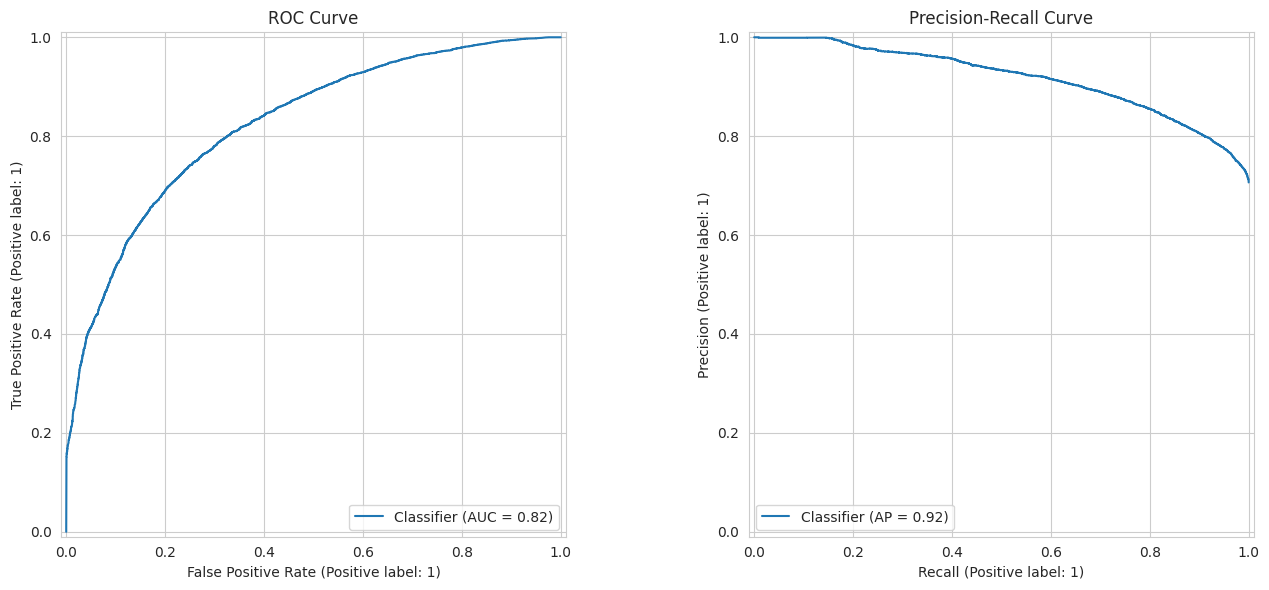

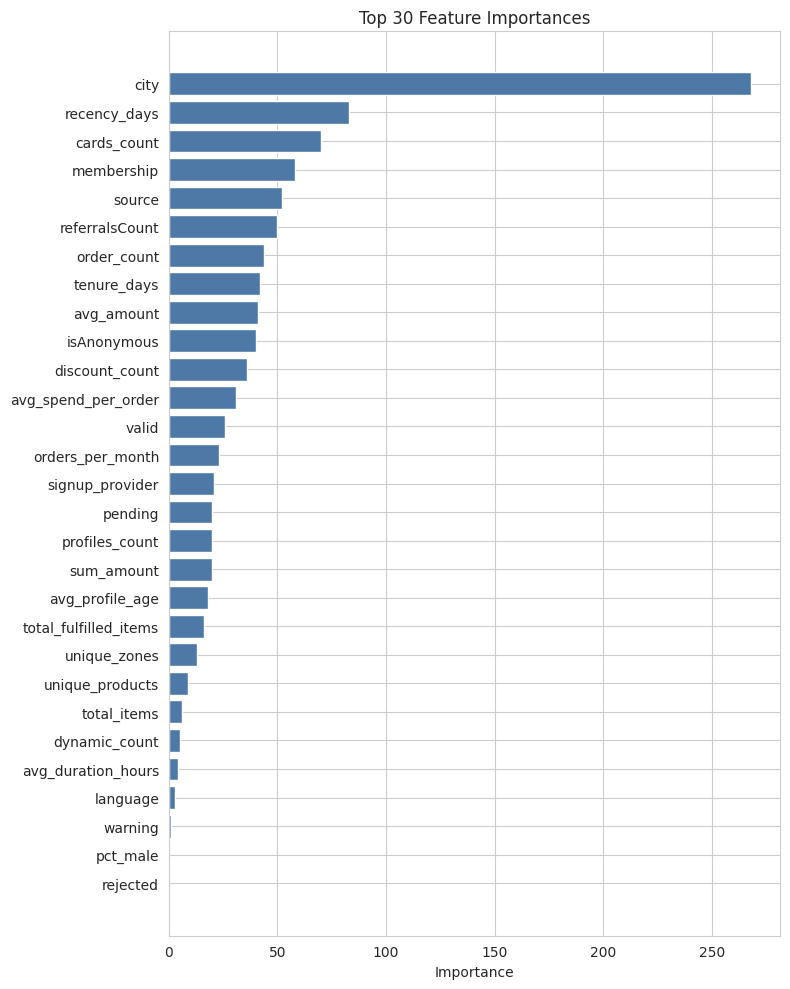

In [94]:
# Parameters
TARGET = 'churn'
EXCLUDE = ['user.uid', 'first_order', 'last_order', 'createdAt']  # columns to exclude from features
features = [c for c in df.columns if c not in EXCLUDE + [TARGET]]

#Datasets
X = df[features].copy()
y = df[TARGET]

# Numeric features
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].astype(np.float32)

# Categorical features
cat_cols = X.select_dtypes(include=['object']).columns
for c in cat_cols:
    X[c] = X[c].astype('category')

# Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Handle class imbalance
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()

# LightGBM model parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'seed': 42,
    'scale_pos_weight': scale_pos_weight,
    'num_leaves': 31,
    'max_bin': 255
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50)
]

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols.tolist())
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_cols.tolist())

# Train model
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, valid_data],
    callbacks=callbacks
)

# Predictions and metrics
probs = model.predict(X_test, num_iteration=model.best_iteration)

# ROC AUC
roc = roc_auc_score(y_test, probs)
# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

print(f'ROC AUC: {roc:.4f}')
print(f'PR AUC: {pr_auc:.4f}')

# Classification metrics with 0.5 threshold
preds = (probs >= 0.5).astype(int)
print("Classification Report:\n", classification_report(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
RocCurveDisplay.from_predictions(y_test, probs, ax=axes[0])
axes[0].set_title("ROC Curve")
axes[0].grid(True)

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, probs, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Feature importance
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importance()
}).sort_values('importance', ascending=False).head(30)

plt.figure(figsize=(8,10))
plt.barh(fi['feature'][::-1], fi['importance'][::-1], color='#4E79A7')
plt.title('Top 30 Feature Importances')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### churn with undersampling

/tmp/ipython-input-1672059767.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_bal[c] = X_train_bal[c].astype('category')


Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.854773	valid_1's auc: 0.822653
Early stopping, best iteration is:
[42]	training's auc: 0.85039	valid_1's auc: 0.823248
ROC AUC: 0.8232
PR AUC: 0.9180
              precision    recall  f1-score   support

           0       0.66      0.49      0.56      4030
           1       0.81      0.89      0.85      9700

    accuracy                           0.78     13730
   macro avg       0.73      0.69      0.71     13730
weighted avg       0.76      0.78      0.76     13730

Confusion matrix:
 [[1986 2044]
 [1043 8657]]


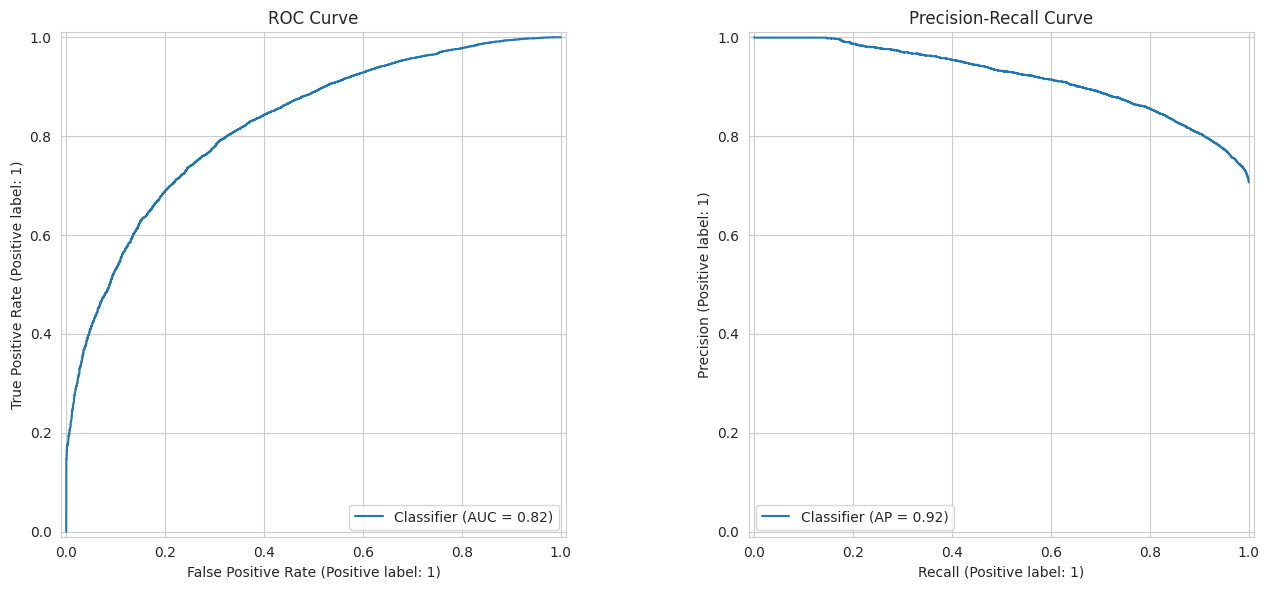

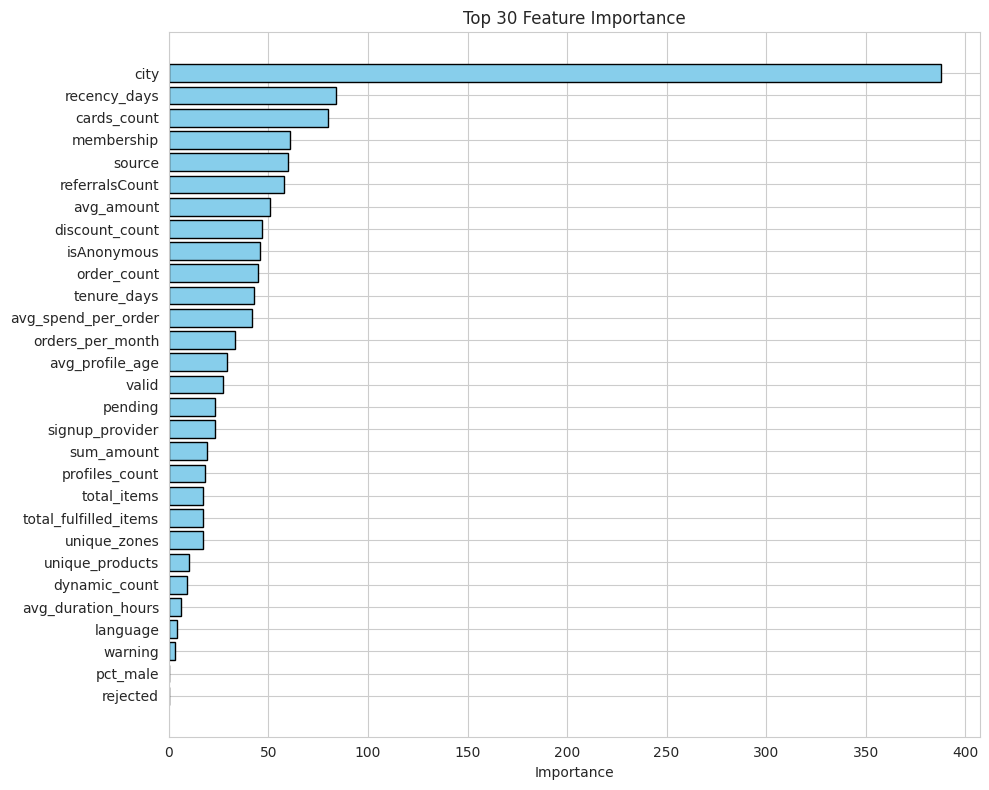

In [95]:
TARGET = 'churn'
EXCLUDE = ['user.uid','first_order','last_order','createdAt']
features = [c for c in df.columns if c not in EXCLUDE + [TARGET]]

# Prepare dataset
X = df[features].copy()
y = df[TARGET]

# Optimize types
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].astype(np.float32)
cat_cols = X.select_dtypes(include=['object']).columns
for c in cat_cols:
    X[c] = X[c].astype('category')

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Undersample majority class
df_train = pd.concat([X_train, y_train], axis=1)
df_majority = df_train[df_train[TARGET]==0]
df_minority = df_train[df_train[TARGET]==1]

n_samples = min(len(df_majority), int(len(df_minority)*3))
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=n_samples,
    random_state=42
)

df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1, random_state=42)
X_train_bal = df_balanced[features]
y_train_bal = df_balanced[TARGET]

# Reconvert categorical features
for c in cat_cols:
    X_train_bal[c] = X_train_bal[c].astype('category')

# LightGBM parameters
params = {
    'objective':'binary',
    'metric':'auc',
    'verbosity':-1,
    'seed':42,
    'num_leaves':31,
    'max_bin':255
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50)
]

train_data = lgb.Dataset(X_train_bal, label=y_train_bal, categorical_feature=cat_cols.tolist())
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_cols.tolist())

# Train
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, valid_data],
    callbacks=callbacks
)

# Predictions and Metrics
probs = model.predict(X_test, num_iteration=model.best_iteration)
roc = roc_auc_score(y_test, probs)
precision, recall, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

print(f'ROC AUC: {roc:.4f}')
print(f'PR AUC: {pr_auc:.4f}')

preds = (probs>=0.5).astype(int)
print(classification_report(y_test, preds))
print('Confusion matrix:\n', confusion_matrix(y_test, preds))

# Plot ROC and Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, probs, ax=axes[0])
axes[0].set_title("ROC Curve")
axes[0].grid(True)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, probs, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Feature Importance
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importance()
}).sort_values('importance', ascending=False).head(30)

plt.figure(figsize=(10,8))
plt.barh(fi['feature'][::-1], fi['importance'][::-1], color='skyblue', edgecolor='black')
plt.title('Top 30 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### churn with SMOTE

Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.933542	valid_1's auc: 0.82412
Early stopping, best iteration is:
[38]	training's auc: 0.928707	valid_1's auc: 0.824391
ROC AUC: 0.8244
PR AUC: 0.9187
              precision    recall  f1-score   support

           0       0.65      0.52      0.58      4030
           1       0.82      0.88      0.85      9700

    accuracy                           0.78     13730
   macro avg       0.73      0.70      0.71     13730
weighted avg       0.77      0.78      0.77     13730

Confusion matrix:
 [[2089 1941]
 [1143 8557]]


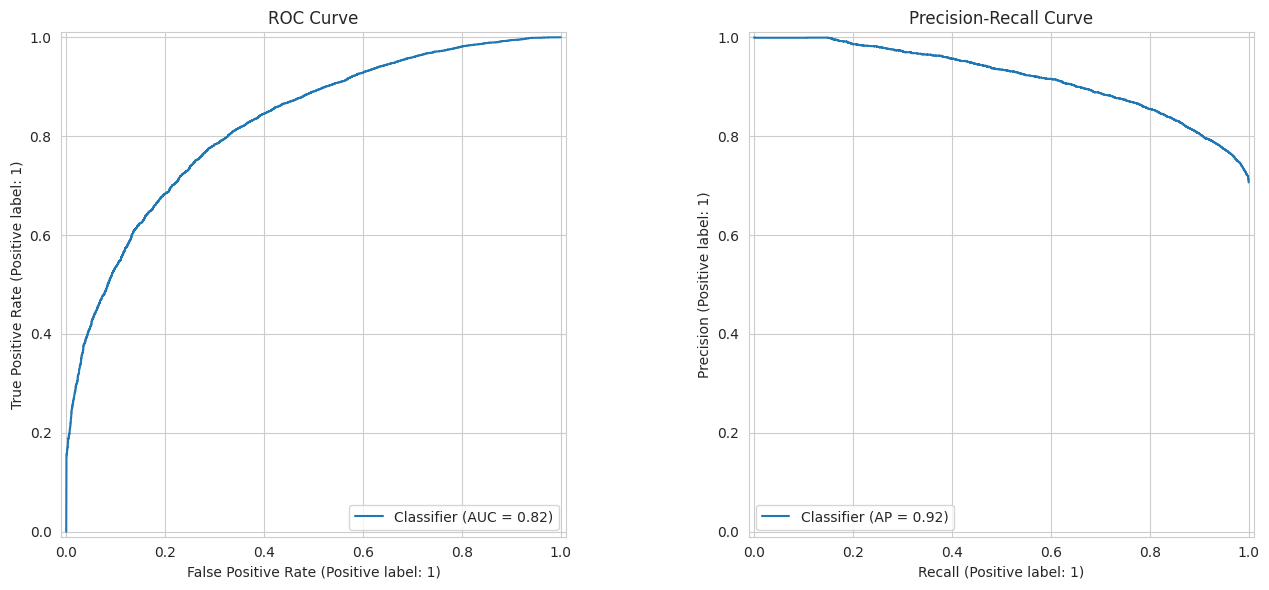

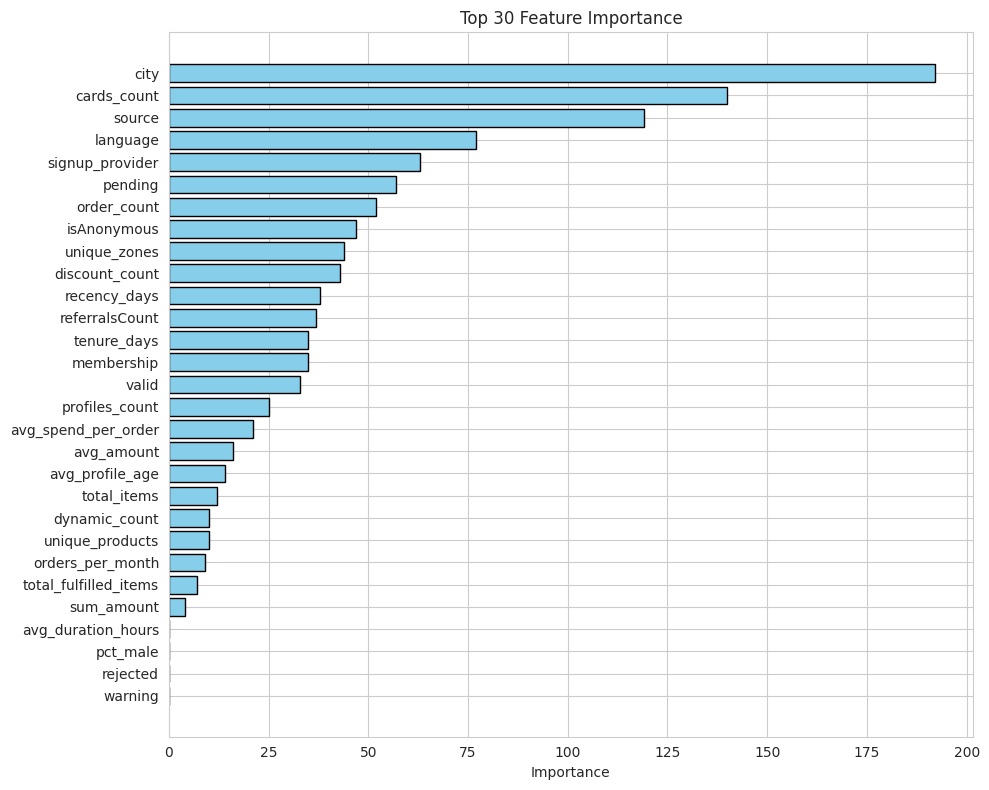

In [96]:
TARGET = 'churn'
EXCLUDE = ['user.uid','first_order','last_order','createdAt']
features = [c for c in df.columns if c not in EXCLUDE + [TARGET]]

X = df[features].copy()
y = df[TARGET]

# Optimize numeric columns
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(0).astype(np.float32)

# Handle categorical columns
cat_cols = X.select_dtypes(include=['object','category']).columns
X[cat_cols] = X[cat_cols].fillna('missing')

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Ordinal encoding for SMOTE
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

X_train_enc[cat_cols] = encoder.fit_transform(X_train_enc[cat_cols])
X_test_enc[cat_cols]  = encoder.transform(X_test_enc[cat_cols])

# Apply SMOTE
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_enc, y_train)

# Convert back to categorical for the model
for c in cat_cols:
    X_train_bal[c] = X_train_bal[c].astype('category')
    X_test_enc[c]  = X_test_enc[c].astype('category')

# LightGBM model parameters
params = {
    'objective':'binary',
    'metric':'auc',
    'verbosity':-1,
    'seed':42,
    'num_leaves':31,
    'max_bin':255
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50)
]

train_data = lgb.Dataset(X_train_bal, label=y_train_bal, categorical_feature=cat_cols.tolist())
valid_data = lgb.Dataset(X_test_enc, label=y_test, reference=train_data, categorical_feature=cat_cols.tolist())

# Train model
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, valid_data],
    callbacks=callbacks
)

# Predictions and Metrics
probs = model.predict(X_test_enc, num_iteration=model.best_iteration)
roc = roc_auc_score(y_test, probs)
precision, recall, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

print(f'ROC AUC: {roc:.4f}')
print(f'PR AUC: {pr_auc:.4f}')

preds = (probs>=0.5).astype(int)
print(classification_report(y_test, preds))
print('Confusion matrix:\n', confusion_matrix(y_test, preds))

# Plot ROC & Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, probs, ax=axes[0])
axes[0].set_title("ROC Curve")
axes[0].grid(True)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, probs, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Feature Importance
fi = pd.DataFrame({
    'feature': X_train_bal.columns,
    'importance': model.feature_importance()
}).sort_values('importance', ascending=False).head(30)

plt.figure(figsize=(10,8))
plt.barh(fi['feature'][::-1], fi['importance'][::-1], color='skyblue', edgecolor='black')
plt.title('Top 30 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### Code to compare models


--- Training LightGBM ---
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.823325	valid_0's binary_logloss: 0.507984
Early stopping, best iteration is:
[17]	valid_0's auc: 0.822169	valid_0's binary_logloss: 0.504474
ROC AUC: 0.8222, PR AUC: 0.9175

--- Training RandomForest ---
ROC AUC: 0.8068, PR AUC: 0.9106

--- Training LogisticRegression ---
ROC AUC: 0.8086, PR AUC: 0.9089

--- Model Comparison ---
                model   roc_auc    pr_auc
0            LightGBM  0.822169  0.917480
1        RandomForest  0.806827  0.910554
2  LogisticRegression  0.808625  0.908912


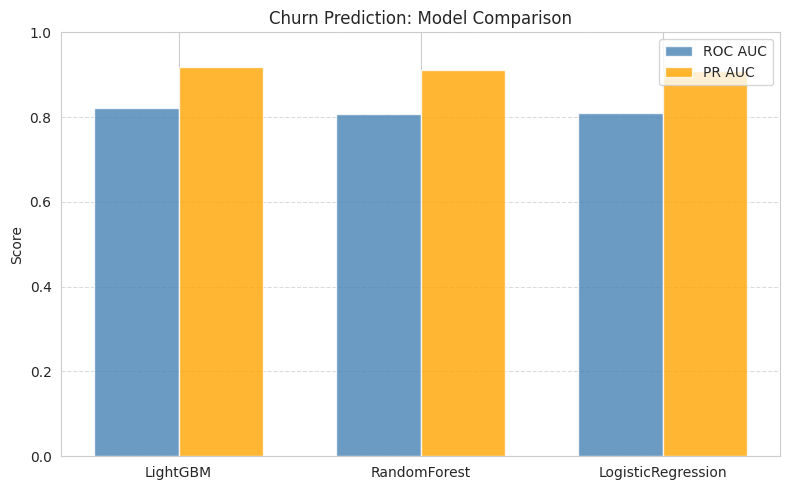

In [97]:
# Target and features
TARGET = 'churn'
EXCLUDE = ['user.uid','first_order','last_order','createdAt']
features = [c for c in df.columns if c not in EXCLUDE + [TARGET]]

X = df[features].copy()
y = df[TARGET]

# Optimize numeric types and define categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].astype(np.float32)
cat_cols = X.select_dtypes(include=['object','category']).columns
for c in cat_cols:
    X[c] = X[c].astype('category')

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Define models
models = {
    'LightGBM': lgb.LGBMClassifier(
        objective='binary',
        n_estimators=500,
        num_leaves=31,
        max_bin=255,
        random_state=42,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum()
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    'LogisticRegression': LogisticRegression(
        solver='lbfgs',
        max_iter=500,
        class_weight='balanced',
        n_jobs=-1
    )
}

# Train, predict, and evaluate
results = []

for name, model in models.items():
    print(f"\n--- Training {name} ---")

    if name == 'LightGBM':
        # LightGBM can use categorical features directly
        cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]
        model.fit(
            X_train, y_train,
            categorical_feature=cat_idx,
            eval_set=[(X_test, y_test)],
            eval_metric='auc',
            callbacks=[lgb.log_evaluation(50), lgb.early_stopping(50)]
        )
        probs = model.predict_proba(X_test)[:,1]
    else:
        # Other models use one-hot encoding
        X_train_enc = pd.get_dummies(X_train, columns=cat_cols)
        X_test_enc = pd.get_dummies(X_test, columns=cat_cols)
        # Align test columns to train columns
        X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
        model.fit(X_train_enc, y_train)
        probs = model.predict_proba(X_test_enc)[:,1]

    # Compute metrics
    roc = roc_auc_score(y_test, probs)
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall, precision)

    results.append({'model': name, 'roc_auc': roc, 'pr_auc': pr_auc})
    print(f"ROC AUC: {roc:.4f}, PR AUC: {pr_auc:.4f}")

# Results
results_df = pd.DataFrame(results)
print("\n--- Model Comparison ---")
print(results_df)

# Comparative plot
plt.figure(figsize=(8,5))
bar_width = 0.35
x = np.arange(len(results_df['model']))

plt.bar(x - bar_width/2, results_df['roc_auc'], width=bar_width, alpha=0.8, label='ROC AUC', color='steelblue')
plt.bar(x + bar_width/2, results_df['pr_auc'], width=bar_width, alpha=0.8, label='PR AUC', color='orange')
plt.xticks(x, results_df['model'])
plt.ylabel("Score")
plt.title("Churn Prediction: Model Comparison")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


# SENTIMENT ANALYSIS

## Loading Data



In [98]:
reviews_df = pd.read_csv("reviews.csv")
reviews_df

,review.uid,user.uid,text
0,1,tcdf7enqg9sxqq4ie4qh3xzjbt,I have bought several of the Vitality canned d...
1,2,kszpqbggktbzmtkkkejthwyucw,Product arrived labeled as Jumbo Salted Peanut...
2,3,l01hczdvthqra6hsxbovmqipdc,This is a confection that has been around a fe...
3,4,cmszp7l1j9pt53fvt178v3avxd,If you are looking for the secret ingredient i...
4,5,bhimnczlhxddegbdaytb7gbhx2,Great taffy at a great price. There was a wid...
...,...,...,...
105705,140942,aucpq6co8tbk8qelhzezxa4rkm,"We Love,Love our Keurig coffee maker .My husba..."
105706,140943,bybi8rqc0odzbnbdlohrlqp9jt,This is supposed to be a light roast coffee bu...
105707,140944,lnp0swzvbkuhvqvdx0ctmjwn7v,I have always been happy with my Kcups but thi...
105708,140945,miyvfildj9cxsn27tqt3khp6gt,I ordered light roast coffee and was sent one ...


In [99]:
labelled_df = pd.read_csv("reviews_labelled.csv")
labelled_df

,labelled_review.uid,text,sentiment_label
0,0,I'm no bitters expert but I bought it as a gif...,neutral
1,1,"these are probably great in the right drinks, ...",neutral
2,2,I sent these to my dad for his bday and he sai...,positive
3,3,I purchased these as a gift for family member ...,positive
4,4,My wife bought me this sauce sampler for Chris...,neutral
...,...,...,...
462739,462739,Great for sesame chicken..this is a good if no...,positive
462740,462740,I'm disappointed with the flavor. The chocolat...,neutral
462741,462741,"These stars are small, so you can give 10-15 o...",positive
462742,462742,These are the BEST treats for training and rew...,positive


## Data Exploration

In [100]:
# Dataset dimensions
print(" Labelled dataset shape:", labelled_df.shape)
print(" Reviews dataset shape:", reviews_df.shape)

# Preview samples
print("\n Sample from labelled dataset:\n", labelled_df.head())
print("\n Sample from reviews dataset:\n", reviews_df.head())

# Null value check
print("\n Missing values in labelled dataset:\n", labelled_df.isnull().sum())
print("\n Missing values in reviews dataset:\n", reviews_df.isnull().sum())

# Label distribution
print("\n Sentiment label distribution:\n", labelled_df['sentiment_label'].value_counts())


 Labelled dataset shape: (462744, 3)
 Reviews dataset shape: (105710, 3)

 Sample from labelled dataset:
    labelled_review.uid                                               text  \
0                    0  I'm no bitters expert but I bought it as a gif...   
1                    1  these are probably great in the right drinks, ...   
2                    2  I sent these to my dad for his bday and he sai...   
3                    3  I purchased these as a gift for family member ...   
4                    4  My wife bought me this sauce sampler for Chris...   

  sentiment_label  
0         neutral  
1         neutral  
2        positive  
3        positive  
4         neutral  

 Sample from reviews dataset:
    review.uid                    user.uid  \
0           1  tcdf7enqg9sxqq4ie4qh3xzjbt   
1           2  kszpqbggktbzmtkkkejthwyucw   
2           3  l01hczdvthqra6hsxbovmqipdc   
3           4  cmszp7l1j9pt53fvt178v3avxd   
4           5  bhimnczlhxddegbdaytb7gbhx2   

        

## Text Cleaning

In [101]:
# Download all required resources safely
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [102]:
# Preprocessing setup
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isnull(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # Rebuild the text
    return " ".join(tokens)

# Apply text cleaning
labelled_df['clean_text'] = labelled_df['text'].apply(clean_text)
reviews_df['clean_text'] = reviews_df['text'].apply(clean_text)

# Preview cleaned text
print("\nExample of original vs cleaned text:")
print(labelled_df[['text', 'clean_text']].head())



Example of original vs cleaned text:
                                                text  \
0  I'm no bitters expert but I bought it as a gif...   
1  these are probably great in the right drinks, ...   
2  I sent these to my dad for his bday and he sai...   
3  I purchased these as a gift for family member ...   
4  My wife bought me this sauce sampler for Chris...   

                                          clean_text  
0  im bitter expert bought gift friend surprised ...  
1  probably great right drink dont like old fashi...  
2  sent dad bday said really pretty good he hard ...  
3  purchased gift family member love bbq pork war...  
4  wife bought sauce sampler christmas knowing lo...  


## Feature and labels Preparation

In [103]:
# Define X and y
X = labelled_df['clean_text']        # Feature: cleaned text
y = labelled_df['sentiment_label']   # Target: original labels

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Check correspondence between original and encoded labels
print("Classes found:", le.classes_)
print("Example mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Example output
print("\nFirst 10 encoded values:", y_encoded[:10])


Classes found: ['negative' 'neutral' 'positive']
Example mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

First 10 encoded values: [1 1 2 2 1 2 2 2 2 2]


## TF-IDF Vectorization

In [104]:
# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000,    # Use at most 20,000 features
    ngram_range=(1, 2),    # Consider both single words and pairs of words
    min_df=5,              # Keep only terms that appear in at least 5 documents
    max_df=0.8             # Ignore terms that appear in more than 80% of documents (not informative).
)

# Train the vectorizer and transform the text data
X_tfidf = tfidf.fit_transform(X)

# Inspect the result
print("Shape of the TF-IDF matrix:", X_tfidf.shape)


Shape of the TF-IDF matrix: (462744, 20000)


### Save the vectorizer



In [105]:

# Save the trained TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']

## Training & Evaluation

In [106]:
# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42,     # Ensures reproducibility of the split
    stratify=y_encoded   # Same class proportions in train and test
)

# Display the number of samples in each set
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (370195, 20000)
Test set size: (92549, 20000)


### Logistic Regression


 Logistic Regression Results
Accuracy: 0.8118618245469967

Classification Report:
               precision    recall  f1-score   support

    negative       0.78      0.63      0.70      8470
     neutral       0.71      0.59      0.65     24677
    positive       0.85      0.93      0.89     59402

    accuracy                           0.81     92549
   macro avg       0.78      0.72      0.74     92549
weighted avg       0.80      0.81      0.81     92549



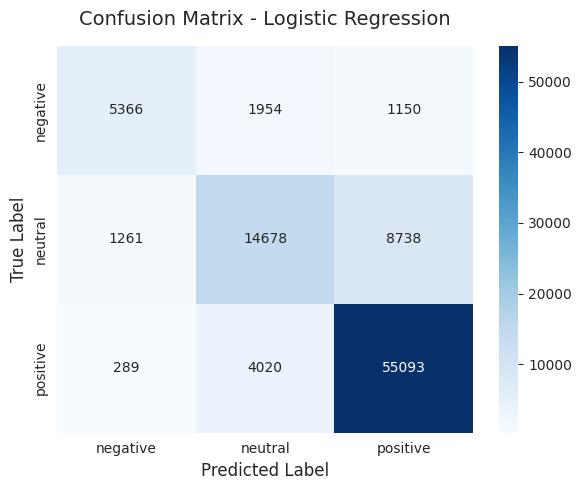

In [107]:
logreg = LogisticRegression(
    max_iter=1000,   # Increase iterations to ensure convergence
    n_jobs=-1        # Use all CPU cores for faster training
)

# Train the model
logreg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_logreg = logreg.predict(X_test)

# Evaluate the model
print("\n Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Logistic Regression", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


### Naive Bayes



In [108]:
nb = MultinomialNB()

# Train the model
nb.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb.predict(X_test)

# Evaluate the model
print("\n Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb, target_names=le.classes_))



 Naive Bayes Results
Accuracy: 0.7635090600654788

Classification Report:
               precision    recall  f1-score   support

    negative       0.78      0.41      0.53      8470
     neutral       0.68      0.44      0.53     24677
    positive       0.78      0.95      0.86     59402

    accuracy                           0.76     92549
   macro avg       0.75      0.60      0.64     92549
weighted avg       0.75      0.76      0.74     92549



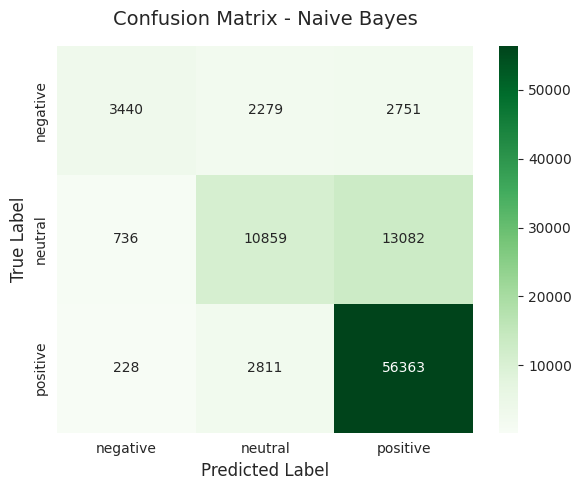

In [109]:
# Confusion Matrix Visualization for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True, fmt='d', cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Naive Bayes", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


### CNN

#### Embedding




In [110]:
# Parameters
MAX_WORDS = 20000   # Maximum vocabulary size
MAX_LEN = 200       # Maximum sequence length

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# Fit the tokenizer on the text data
tokenizer.fit_on_texts(labelled_df['clean_text'])

# Convert texts to sequences of integers
X_seq = tokenizer.texts_to_sequences(labelled_df['clean_text'])

# Pad sequences to ensure consistent length
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post')

# Results
print("Shape of padded sequences:", X_pad.shape)


Shape of padded sequences: (462744, 200)


#### CNN model

In [111]:
# Parameters
EMBED_DIM = 100  # Dimension of the word embeddings

# CNN model
model = Sequential([
    # Embedding layer: maps each word index to a dense vector
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),

    # 1D Convolution layer: detects local patterns in word sequences
    Conv1D(filters=128, kernel_size=5, activation='relu'),

    # Global Max Pooling: reduces each feature map to its maximum value
    GlobalMaxPooling1D(),

    # Fully connected layer
    Dense(64, activation='relu'),

    # Dropout layer: reduces overfitting by randomly dropping 50% of neurons during training
    Dropout(0.5),

    # Output layer: 3 units for 3 classes (negative, neutral, positive) with softmax activation
    Dense(3, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Inspect the model
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Train and Test Split

In [112]:
# Split the padded sequences into training and test sets, keeping the same proportion of classes in both sets using stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Train the CNN model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,       # Number of training iterations over the full dataset
    batch_size=128  # Number of samples per gradient update
)


Epoch 1/5
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 901s 311ms/step - accuracy: 0.7381 - loss: 0.6264 - val_accuracy: 0.8156 - val_loss: 0.4590
Epoch 2/5
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 920s 318ms/step - accuracy: 0.8475 - loss: 0.3971 - val_accuracy: 0.8334 - val_loss: 0.4283
Epoch 3/5
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 935s 322ms/step - accuracy: 0.8978 - loss: 0.2772 - val_accuracy: 0.8385 - val_loss: 0.4535
Epoch 4/5
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 939s 325ms/step - accuracy: 0.9324 - loss: 0.1890 - val_accuracy: 0.8375 - val_loss: 0.5350
Epoch 5/5
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 895s 309ms/step - accuracy: 0.9524 - loss: 0.1345 - val_accuracy: 0.8227 - val_loss: 0.5972


#### Evaluation

In [113]:
loss, acc = model.evaluate(X_test, y_test)

print(f" CNN Test Accuracy: {acc:.4f}")


2893/2893 ━━━━━━━━━━━━━━━━━━━━ 67s 23ms/step - accuracy: 0.8242 - loss: 0.5884
 CNN Test Accuracy: 0.8227


2893/2893 ━━━━━━━━━━━━━━━━━━━━ 63s 22ms/step


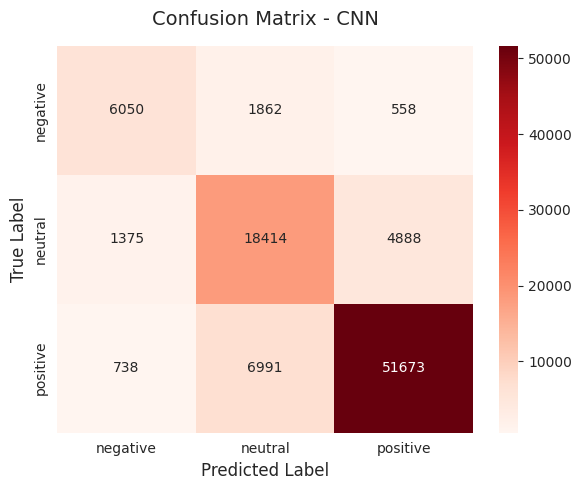

In [114]:
# Predict probabilities for the test set
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

# Compute the confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_cnn,
    annot=True, fmt='d', cmap="Reds",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - CNN", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


## Apply the best model to REVIEWS

In [115]:
# Transform the text into TF-IDF features using the same vectorizer
X_reviews_tfidf = tfidf.transform(reviews_df['clean_text'])

# Predict sentiment labels
pred_labels_encoded = logreg.predict(X_reviews_tfidf)

# Decode integer labels back to original text labels
pred_labels_text = le.inverse_transform(pred_labels_encoded)

# Create a new DataFrame including predictions
reviews_pred_df = reviews_df.copy()
reviews_pred_df['predicted_sentiment'] = pred_labels_text

# Display sample predictions
print(reviews_pred_df.head())


   review.uid                    user.uid  \
0           1  tcdf7enqg9sxqq4ie4qh3xzjbt   
1           2  kszpqbggktbzmtkkkejthwyucw   
2           3  l01hczdvthqra6hsxbovmqipdc   
3           4  cmszp7l1j9pt53fvt178v3avxd   
4           5  bhimnczlhxddegbdaytb7gbhx2   

                                                text  \
0  I have bought several of the Vitality canned d...   
1  Product arrived labeled as Jumbo Salted Peanut...   
2  This is a confection that has been around a fe...   
3  If you are looking for the secret ingredient i...   
4  Great taffy at a great price.  There was a wid...   

                                          clean_text predicted_sentiment  
0  bought several vitality canned dog food produc...            positive  
1  product arrived labeled jumbo salted peanutsth...            positive  
2  confection around century light pillowy citrus...            positive  
3  looking secret ingredient robitussin believe f...            positive  
4  great taffy gr

### Saving the dataset with predictions

In [116]:
reviews_pred_df

,review.uid,user.uid,text,clean_text,predicted_sentiment
0,1,tcdf7enqg9sxqq4ie4qh3xzjbt,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...,positive
1,2,kszpqbggktbzmtkkkejthwyucw,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,positive
2,3,l01hczdvthqra6hsxbovmqipdc,This is a confection that has been around a fe...,confection around century light pillowy citrus...,positive
3,4,cmszp7l1j9pt53fvt178v3avxd,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...,positive
4,5,bhimnczlhxddegbdaytb7gbhx2,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,positive
...,...,...,...,...,...
105705,140942,aucpq6co8tbk8qelhzezxa4rkm,"We Love,Love our Keurig coffee maker .My husba...",lovelove keurig coffee maker husband life brea...,positive
105706,140943,bybi8rqc0odzbnbdlohrlqp9jt,This is supposed to be a light roast coffee bu...,supposed light roast coffee state extra bold l...,negative
105707,140944,lnp0swzvbkuhvqvdx0ctmjwn7v,I have always been happy with my Kcups but thi...,always happy kcups particular box good made cu...,negative
105708,140945,miyvfildj9cxsn27tqt3khp6gt,I ordered light roast coffee and was sent one ...,ordered light roast coffee sent one box light ...,neutral


In [117]:
reviews_pred_df.to_csv("REVIEWS_with_sentiment.csv", index=False)

## Exploratory analysis of predictions

In [118]:
# Loading Data
reviews_pred_df = pd.read_csv("REVIEWS_with_sentiment.csv")

/tmp/ipython-input-3280615818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


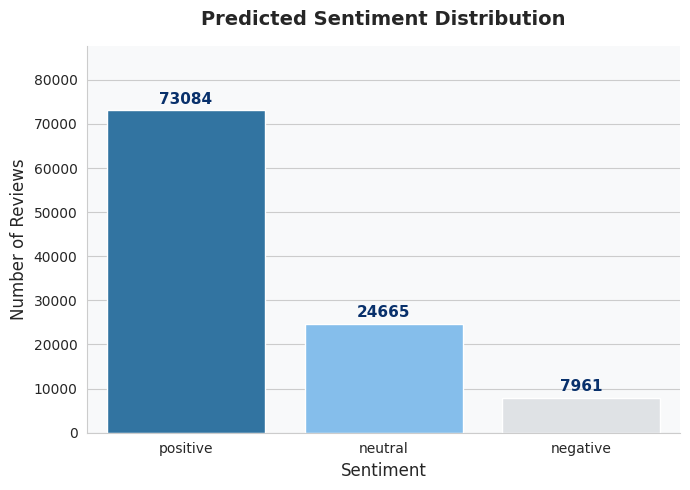

In [119]:
# Count the number of reviews for each predicted sentiment
sentiment_counts = reviews_pred_df['predicted_sentiment'].value_counts()

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    palette=["#1f77b4", "#74c0fc", "#dee2e6"]
)

plt.title("Predicted Sentiment Distribution", fontsize=14, pad=15, fontweight="bold")
plt.ylabel("Number of Reviews", fontsize=12)
plt.xlabel("Sentiment", fontsize=12)

# Values annotations
for i, count in enumerate(sentiment_counts.values):
    plt.text(i, count + (max(sentiment_counts.values) * 0.02),
             str(count), ha='center', fontsize=11, fontweight="bold", color="#08306b")

plt.gca().set_facecolor("#f8f9fa")
sns.despine()

plt.ylim(0, max(sentiment_counts.values) * 1.2)
plt.tight_layout()
plt.show()


### Analysis by user

In [120]:
# Count the number of predicted sentiments per user
user_sentiment = reviews_pred_df.groupby(['user.uid', 'predicted_sentiment']).size().unstack(fill_value=0)

# Identify users with the most negative reviews
top_negative_users = user_sentiment.sort_values(by='negative', ascending=False).head(10)

# Results
print("Top 10 users with the most negative reviews:\n", top_negative_users)



Top 10 users with the most negative reviews:
 predicted_sentiment         negative  neutral  positive
user.uid                                               
twkxylfjtenz98tvlugv5a5gu8         1        0         0
twlbfag8ihebui44jiqr1cpvnu         1        0         0
ffhh9attqdhhfnftwzbimeu2xj         1        0         0
qj7dechokwr8cwgiawdx71omuq         1        0         0
qj7bgphnehohkf2vqzzm00htnk         1        0         0
xju5ccghuwugnmpwoo7tny5p1w         1        0         0
ffiuld2rfzf3zkkxrtd7af0j1m         1        0         0
irwz88kkuag5nccre4in6xkqqh         1        0         0
5ixonvp9z5niwk1uc3lmguz2jp         1        0         0
js4dnfmluvf0ja3ps4ttnezvmf         1        0         0


### Analysis by text




In [121]:
# Top 5 longest positive reviews
print("Top 5 Longest Positive Reviews:")
longest_positive = reviews_pred_df[reviews_pred_df['predicted_sentiment'] == 'positive'] \
    .sort_values(by='text', key=lambda x: x.str.len(), ascending=False)['text'].head()
print(longest_positive)

# Top 5 longest negative reviews
print("\nTop 5 Longest Negative Reviews:")
longest_negative = reviews_pred_df[reviews_pred_df['predicted_sentiment'] == 'negative'] \
    .sort_values(by='text', key=lambda x: x.str.len(), ascending=False)['text'].head()
print(longest_negative)


Top 5 Longest Positive Reviews:
51534     **********************************************...
7448      We breastfeed our month old boy, but since his...
73203     Update: 3-9-12<br /><br />Tomorrow marks the s...
103512    Unfortunately most people are ill informed abo...
93627     EXCELLENT CHRISTMAS gift or for birthday any t...
Name: text, dtype: object

Top 5 Longest Negative Reviews:
44836     My dog loved this the first few meals then was...
67244     Chef Michael's Sirloin Steak dog food is candy...
102317    Something about the Brooklyn Bridge compelled ...
73465     This review will make me sound really stupid, ...
39374     This review will make me sound really stupid, ...
Name: text, dtype: object


In [122]:
# Negative reviews
reviews_pred_df[reviews_pred_df['predicted_sentiment'] == 'negative']["text"]

,text
34,This is the same stuff you can buy at the big ...
42,Arrived in 6 days and were so stale i could no...
45,"I purchased the Mango flavor, and to me it doe..."
50,Buyer Beware Please! This sweetener is not for...
69,I fed this to my Golden Retriever and he hated...
...,...
105654,yet another dog treat made in China. I'm think...
105666,I bought this item and last weekend ate quite ...
105690,1 star is far too good..it deserves nothing.I ...
105706,This is supposed to be a light roast coffee bu...


### Sentiment Percentages

Predicted Sentiment Percentages:
 predicted_sentiment
positive    69.14
neutral     23.33
negative     7.53
Name: count, dtype: float64


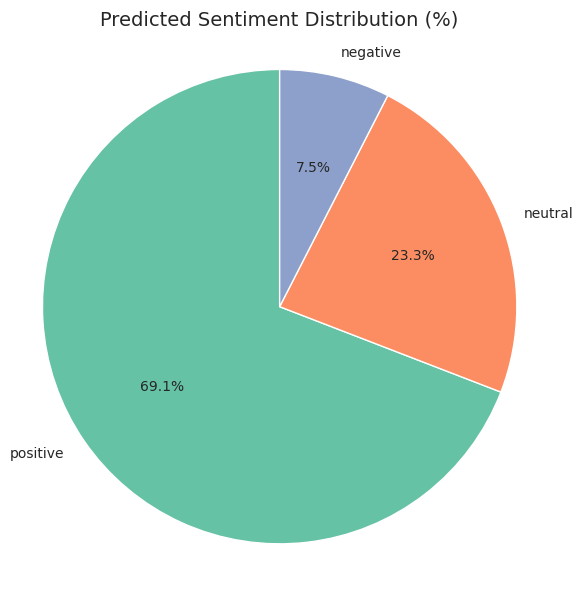

In [123]:
# Calculate the percentage of each predicted sentiment
sentiment_percent = 100 * sentiment_counts / sentiment_counts.sum()
print("Predicted Sentiment Percentages:\n", sentiment_percent.round(2))

# Plot
plt.figure(figsize=(6,6))
plt.pie(
    sentiment_percent,
    labels=sentiment_percent.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2"),
    startangle=90
)

plt.title("Predicted Sentiment Distribution (%)", fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()


## Further information

### Users with multiple negative/positive reviews

In [124]:
# Count the number of predicted sentiments per user
user_sentiment = reviews_pred_df.groupby(['user.uid', 'predicted_sentiment']).size().unstack(fill_value=0)

# Identify users with the most negative reviews
top_negative_users = user_sentiment.sort_values(by='negative', ascending=False).head(10)

# Identify users with the most positive reviews
top_positive_users = user_sentiment.sort_values(by='positive', ascending=False).head(10)

# Results
print(" Top 10 Users with the Most Negative Reviews:\n", top_negative_users)
print("\n Top 10 Users with the Most Positive Reviews:\n", top_positive_users)


 Top 10 Users with the Most Negative Reviews:
 predicted_sentiment         negative  neutral  positive
user.uid                                               
twkxylfjtenz98tvlugv5a5gu8         1        0         0
twlbfag8ihebui44jiqr1cpvnu         1        0         0
ffhh9attqdhhfnftwzbimeu2xj         1        0         0
qj7dechokwr8cwgiawdx71omuq         1        0         0
qj7bgphnehohkf2vqzzm00htnk         1        0         0
xju5ccghuwugnmpwoo7tny5p1w         1        0         0
ffiuld2rfzf3zkkxrtd7af0j1m         1        0         0
irwz88kkuag5nccre4in6xkqqh         1        0         0
5ixonvp9z5niwk1uc3lmguz2jp         1        0         0
js4dnfmluvf0ja3ps4ttnezvmf         1        0         0

 Top 10 Users with the Most Positive Reviews:
 predicted_sentiment         negative  neutral  positive
user.uid                                               
zzxaa4iuo4fnkdl2q13q71iu6g         0        0         1
005bg1dx4mxrhsdjqmpwxr4rni         0        0         1
00a3sq7bg